# Bank Marketing Campaign Optimization: Predicting Term Deposit Subscription

Created By : Gamma Group 

             1. Nurul Balqis Apriany 

             2. Muhamad Fahrizal Safalah

---

# Business Problem Understanding

## Context

A banking institution runs a marketing campaign through telemarketing to offer a **term deposit** product to its customers. A term deposit is a banking product where customers deposit their money for a certain period of time and receive returns or interest based on the bank’s terms and conditions.

In practice, not every customer contacted by the bank will be interested or eventually subscribe to the term deposit product. If the bank contacts all customers without prioritization, the campaign process may become inefficient because it requires a significant amount of agent time, operational cost, and marketing resources.

This dataset contains information about customer profiles, customer financial conditions, current campaign information, previous campaign history, and economic indicators at the time the campaign was conducted. This information can be used to help the bank predict which customers are more likely to subscribe to a term deposit.

Target:

0 : Customer does not subscribe to term deposit  
1 : Customer subscribes to term deposit

---

## **Problem Statement**

Telemarketing campaigns require cost, time, and agent effort. If all customers are contacted without any selection or prioritization process, the bank may spend its resources on customers who have a low probability of subscribing to a term deposit.

In addition, based on the dataset, the number of customers who subscribe to a term deposit is much lower than the number of customers who do not subscribe. This indicates that the campaign conversion rate is relatively low, so the bank needs a better strategy to understand which customers are more likely to subscribe and which customers should be prioritized.

From the business perspective, this problem affects telemarketing agents and marketing managers. Agents may spend time contacting low-potential customers, while marketing managers need a more efficient strategy to improve campaign conversion.

Therefore, this project focuses on two main problems. First, it aims to identify the customer profile, campaign, previous campaign, and economic factors that are associated with a higher tendency to subscribe to a term deposit. Second, it aims to build a machine learning model that can predict whether a customer is likely to subscribe or not, so the bank can determine which customers should become the main priority for telemarketing campaigns.

The problem statement of this project is:

**How can the bank identify the key factors that influence customers' tendency to subscribe to a term deposit and predict which customers should be prioritized in telemarketing campaigns to improve campaign efficiency?**

---

## **Goals**

Based on the business problem, the goals of this project are:

1. To identify the key factors that influence customers' tendency to subscribe to a term deposit, based on customer profile, campaign information, previous campaign history, and economic indicators.

2. To build a classification model that can predict whether a customer is likely to subscribe to a term deposit or not.

3. To help the bank prioritize high-potential customers for telemarketing campaigns, reduce inefficient calls to low-potential customers, and improve campaign efficiency.

---

## Analytic Approach

The approach used in this project is **supervised learning** with a **binary classification** method, because the target variable consists of two classes: customers who subscribe and customers who do not subscribe to a term deposit.

First, **Exploratory Data Analysis (EDA)** will be conducted to understand patterns and relationships between customer characteristics, financial conditions, campaign information, previous campaign history, economic indicators, and customer subscription behavior.

After that, several classification algorithms will be compared using the same preprocessing pipeline. Logistic Regression will be used as the baseline model, while other models will be used as comparison models to capture more complex patterns in the data.

The models that will be compared include:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting / XGBoost
- KNN

The best model will be selected based on the main evaluation metric, which is **F-beta Score (β > 1) for the positive class (`yes`)**.

The output of the model will be a prediction and probability of whether a customer will subscribe to a term deposit. These results can be used to create a customer priority list, so the marketing team can focus on customers with a higher probability of subscribing.

---

## Metric Evaluation

In this project, the target variable consists of two classes:

- Positive class: customer subscribes to a term deposit (`yes`)
- Negative class: customer does not subscribe to a term deposit (`no`)

The dataset is considered an **imbalanced dataset**, because the number of customers who subscribe to a term deposit is much lower than the number of customers who do not subscribe. Therefore, accuracy is not suitable as the main evaluation metric, because a model can still achieve high accuracy by mostly predicting the majority class, which is `no`.

In this business context, there are two types of prediction errors:

### Type 1 Error: False Positive

The model predicts that a customer will subscribe, but the customer actually does not subscribe.

Consequences:

- Telemarketing agents may contact customers who are not potential subscribers.
- Campaign time and effort become less efficient.
- Marketing resources may be spent on customers with low interest.

### Type 2 Error: False Negative

The model predicts that a customer will not subscribe, but the customer actually has the potential to subscribe.

Consequences:

- The bank may miss potential customers who are likely to subscribe.
- Potential subscribers are not prioritized in the campaign.
- The campaign may lose opportunities to improve conversion.

Based on these consequences, this project uses **F-beta Score for the positive class (`yes`)** as the primary evaluation metric.

F-beta Score is selected because it is suitable for imbalanced classification problems and can evaluate model performance by considering the trade-off between correctly identifying potential subscribers and reducing incorrect positive predictions. Since this project focuses on finding customers who are more likely to subscribe, **F-beta Score with β > 1** is used to give more emphasis to the positive class (`yes`).

By using **F-beta Score (β > 1)**, the model can be evaluated based on how well it identifies potential subscribers while still maintaining a reasonable balance in prediction performance.

**Primary Metric:**

- **F-beta Score (β > 1) for class `yes`**

**Supporting Metrics:**

- ROC-AUC
- PR-AUC
- Confusion Matrix


---

# Data Understanding

Dataset source : https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset

This dataset contains data from a bank marketing campaign conducted through telemarketing. Each row represents one customer or one campaign contact, including information about the customer profile, financial condition, campaign details, previous campaign history, economic indicators, and the final outcome of whether the customer subscribed to a term deposit or not.

## Dataset Overview

The dataset consists of several feature groups:

1. **Customer Profile**  
   Contains general customer information such as age, job, marital status, and education.

2. **Financial Condition**  
   Contains customer financial condition information such as credit default status, housing loan, and personal loan.

3. **Current Campaign Information**  
   Contains information about the current campaign, such as contact method, contact month, contact day, call duration, and number of contacts during the current campaign.

4. **Previous Campaign Information**  
   Contains information about previous campaigns, such as the number of previous contacts, number of days since the last contact, and the outcome of the previous campaign.

5. **Economic Indicators**  
   Contains economic indicators that describe the economic condition when the campaign was conducted, such as employment variation rate, consumer price index, consumer confidence index, Euribor 3-month rate, and number of employees.

6. **Target Variable**  
   Contains information about whether the customer subscribed to a term deposit or not.

## Note

- The dataset has a binary target, which consists of `yes` and `no`.
- The dataset is imbalanced because the number of customers who subscribe is much lower than customers who do not subscribe.
- Some features are categorical, such as `job`, `marital`, `education`, `contact`, `month`, and `poutcome`.
- Some features are numerical, such as `age`, `duration`, `campaign`, `pdays`, `previous`, and economic indicators.
- There are `unknown` values in several categorical columns.
- The `duration` column needs special attention because it may cause data leakage if the model is used before the phone call is made.

---

# Attribute Information

| Attribute | Data Type | Description |
|---|---|---|
| age | Integer | Customer age |
| job | Text | Customer job type, such as admin, blue-collar, technician, services, management, retired, student, unemployed, and others |
| marital | Text | Customer marital status, such as married, single, divorced, or unknown |
| education | Text | Customer education level, such as university.degree, high.school, basic.9y, professional.course, basic.4y, basic.6y, illiterate, or unknown |
| default | Text | Indicates whether the customer has credit in default |
| housing | Text | Indicates whether the customer has a housing loan |
| loan | Text | Indicates whether the customer has a personal loan |
| contact | Text | Type of communication used to contact the customer, either cellular or telephone |
| month | Text | Last contact month of the current campaign |
| day_of_week | Text | Last contact day of the week, such as mon, tue, wed, thu, or fri |
| duration | Integer | Duration of the last call in seconds. This column needs special attention because it may cause data leakage if the model is used before the call is made |
| campaign | Integer | Number of contacts performed for the customer during the current campaign |
| pdays | Integer | Number of days since the customer was last contacted from a previous campaign. A value of 999 means the customer was not previously contacted |
| previous | Integer | Number of contacts performed for the customer before the current campaign |
| poutcome | Text | Outcome of the previous marketing campaign, such as success, failure, or nonexistent |
| emp.var.rate | Float | Employment variation rate, an indicator of changes in employment conditions |
| cons.price.idx | Float | Consumer price index, an index related to consumer prices and inflation |
| cons.conf.idx | Float | Consumer confidence index, an indicator of consumer confidence in economic conditions |
| euribor3m | Float | Euribor 3-month interest rate |
| nr.employed | Float | Number of employees or employment indicator in the economy |
| y | Text | Target variable that indicates whether the customer subscribed to a term deposit or not |

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import FuncFormatter

In [3]:
# Load Dataset 
df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Number of Rows and Columns
df.shape

(41188, 21)

**Insight:** The dataset consists of **41,188 rows and 21 columns**, providing sufficient customer, campaign, previous campaign, and economic information for exploratory data analysis.

In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Insight:** The dataset has **41,188 records with no missing values across all 21 columns**, consisting of **11 categorical features and 10 numerical features**, making it ready for further exploratory data analysis.

### Unit Analysis
#### The unit of analysis in this dataset is one customer or one campaign contact. Each row represents information about a customer who was contacted during the bank marketing campaign.

In [6]:
column_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Column Category": [
        "Categorical" if dtype == "object" else "Numerical"
        for dtype in df.dtypes
    ]
})

column_types

,Column,Data Type,Column Category
0,age,int64,Numerical
1,job,object,Categorical
2,marital,object,Categorical
3,education,object,Categorical
4,default,object,Categorical
5,housing,object,Categorical
6,loan,object,Categorical
7,contact,object,Categorical
8,month,object,Categorical
9,day_of_week,object,Categorical


**Insight:** The dataset consists of **10 numerical columns and 11 categorical columns**, indicating that it provides a balanced combination of customer characteristics, campaign details, previous campaign history, economic indicators, and the target variable `y` for exploratory data analysis.

In [7]:
# Numeric Data Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


**Insight:** Most customers are in productive age and usually contacted only **1–3 times**, but the existence of very high contact frequency suggests that the bank needs better customer prioritization to avoid inefficient telemarketing efforts.

In [8]:
# Check Missing Values
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

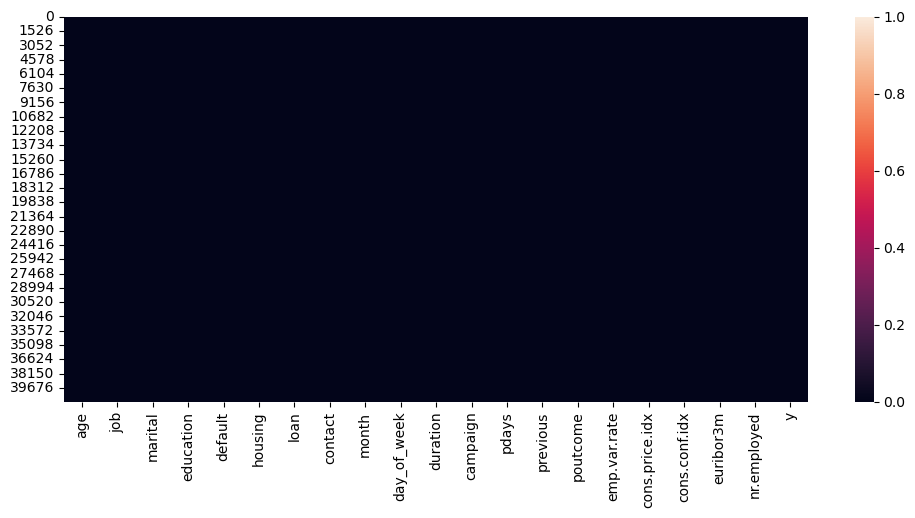

In [9]:
plt.figure(figsize = (12, 5))
sns.heatmap(data = df.isna(), vmin = 0, vmax = 1)
plt.show()

**Insight:** The dataset has **no missing values across all columns**, meaning the data is structurally complete and can be used for EDA without missing-value imputation; however, categorical values such as `unknown` still need to be checked separately because they may represent hidden missing information.

In [10]:
# Check duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 12


**Insight:** The dataset contains only **12 duplicate rows**, which is very small compared to the total data size, but these duplicates should still be removed to avoid repeated customer records affecting the EDA results.

In [11]:
# Checking Inconsistent Values
# Unique values summary for categorical columns
pd.set_option("display.max_colwidth", None)
categorical_cols = df.select_dtypes(include="object").columns
categorical_unique = pd.DataFrame({
    "Column": categorical_cols,
    "Unique Count": [df[col].nunique() for col in categorical_cols],
    "Unique Values": [df[col].unique().tolist() for col in categorical_cols]
})

categorical_unique

,Column,Unique Count,Unique Values
0,job,12,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student]"
1,marital,4,"[married, single, divorced, unknown]"
2,education,8,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate]"
3,default,3,"[no, unknown, yes]"
4,housing,3,"[no, yes, unknown]"
5,loan,3,"[no, yes, unknown]"
6,contact,2,"[telephone, cellular]"
7,month,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, sep]"
8,day_of_week,5,"[mon, tue, wed, thu, fri]"
9,poutcome,3,"[nonexistent, failure, success]"


**Insight:** Several categorical columns contain `unknown` values, especially in customer profile and financial-related features, indicating hidden missing information that should be handled before deeper EDA to avoid misleading customer segmentation.

In [12]:
# Unknown Value Checking
unknown_counts = (df == "unknown").sum()
unknown_counts = unknown_counts[unknown_counts > 0]

unknown_pct = (unknown_counts / len(df) * 100).round(2)

unknown_summary = pd.DataFrame({
    "Unknown Count": unknown_counts,
    "Unknown Percentage (%)": unknown_pct
})

unknown_summary

,Unknown Count,Unknown Percentage (%)
job,330,0.80
marital,80,0.19
education,1731,4.20
default,8597,20.87
housing,990,2.40
loan,990,2.40


**Insight:** Although the dataset has no missing values, several categorical columns contain `unknown` values, especially `default` at **20.87%** and `education` at **4.20%**. This indicates hidden missing information that needs to be handled before deeper EDA, because it may affect customer profiling and campaign segmentation.

In [13]:
# Check potential outliers using IQR method

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

outlier_summary = []

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_percentage = outlier_count / len(df) * 100

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(outlier_percentage, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Outlier Count,Outlier Percentage (%)
0,age,469,1.14
1,duration,2963,7.19
2,campaign,2406,5.84
3,pdays,1515,3.68
4,previous,5625,13.66
5,emp.var.rate,0,0.00
6,cons.price.idx,0,0.00
7,cons.conf.idx,447,1.09
8,euribor3m,0,0.00
9,nr.employed,0,0.00


**Insight:** Outliers are present in several numerical features, with the highest proportions found in `previous` (**13.66%**), `duration` (**7.19%**), and `campaign` (**5.84%**). This indicates that some customers had unusually high previous contacts, call durations, or campaign interactions, which may reflect specific campaign behavior rather than pure data errors. Therefore, these outliers should be reviewed carefully and not removed blindly, because they may contain important business signals for customer targeting.

In [14]:
# Target Distribution 
target_distribution = df["y"].value_counts().reset_index()
target_distribution.columns = ["Target", "Count"]

target_distribution["Percentage"] = (
    df["y"].value_counts(normalize=True).values * 100
).round(2)

target_distribution

,Target,Count,Percentage
0,no,36548,88.73
1,yes,4640,11.27


**Insight:** The target distribution shows a strong imbalance, with only **11.27%** of customers subscribing to a term deposit while **88.73%** did not. This indicates a low campaign conversion rate, so the bank needs a more targeted strategy instead of contacting customers randomly.

## Data Understanding – Insights Summary

- The dataset contains **41,188 rows and 21 columns**, with `y` as the target variable. Each row represents one customer or campaign contact in a bank telemarketing campaign.

- There are **no missing values in NaN format**, but some categorical columns contain `unknown` values:
  - `job`: **330** unknown values (**0.80%**)
  - `marital`: **80** unknown values (**0.19%**)
  - `education`: **1,731** unknown values (**4.20%**)
  - `default`: **8,597** unknown values (**20.87%**)
  - `housing`: **990** unknown values (**2.40%**)
  - `loan`: **990** unknown values (**2.40%**)

  These unknown values will be handled in the data cleaning stage based on domain knowledge — some will be dropped, and some will be imputed.

- The dataset contains **12 duplicated rows**, which will be handled in the data cleaning stage.

- Several numerical features contain potential outliers, especially `previous`, `campaign`, `pdays`, `age`, and `cons.conf.idx`. These values are not removed directly because they may still represent valid customer or campaign behavior, and will be handled carefully during preprocessing.


- The target variable is highly imbalanced, with **88.73% `no`** and **11.27% `yes`**. Therefore, accuracy is not suitable as the main metric, and evaluation should focus on the positive class (`yes`).

- The `duration` column may cause data leakage because it is only known after the call is completed, so it will be reconsidered before modeling.

# Data Cleaning

In this stage, basic data cleaning is performed to prepare the dataset for Exploratory Data Analysis. The cleaning process includes handling duplicated rows and handling `unknown` values based on domain knowledge.

Modeling-specific preprocessing such as encoding, scaling, train-test split, handling imbalance, and removing leakage features will be conducted later in the preprocessing stage.

### Handling Duplicate Rows

The dataset contains 12 duplicate rows.

Duplicate rows are removed to avoid redundant data that may affect analysis results and machine learning model performance.

In [15]:
# Remove duplicate rows
df = df.drop_duplicates()

In [16]:
# Recheck duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [17]:
df.shape

(41176, 21)

**Insight:** After removing **12 duplicate rows**, the dataset contains **41,176 unique records**, ensuring that repeated observations do not bias the EDA results or distort campaign pattern analysis.

### Handling Unknown Values

Several categorical columns contain `unknown` values. These values are handled based on their proportion and business relevance, because they may represent hidden missing information or meaningful customer behavior.

| Column | Unknown % | Strategy | Reasoning |
|--------|-----------|----------|----------|
| `job` | ~0.80% | **Keep as `unknown`** | Although the percentage is small, the `unknown` job category is retained because it may still contain meaningful subscription behavior. Dropping it could remove a customer segment with a different response pattern. |
| `marital` | ~0.19% | **Drop rows** | Based on banking domain knowledge, marital status should fall into clear categories such as `single`, `married`, or `divorced`. Since `unknown` cannot be clearly interpreted for customer profiling and the proportion is very small, these rows are dropped to keep the analysis cleaner. |
| `education` | ~4.20% | **Fill with mode** | Education has a moderate number of `unknown` values. Filling with the mode helps preserve data while maintaining a reasonable representation of the most common education level. |
| `default` | ~20.87% | **Fill with mode** | The `default` column has a high proportion of `unknown` values, so dropping them would remove too much data. Therefore, the values are replaced using the mode to standardize the category based on the most frequent value. |
| `housing` | ~2.40% | **Fill with mode** | Housing loan status has a relatively small proportion of `unknown` values, so mode imputation is used to preserve the records. |
| `loan` | ~2.40% | **Fill with mode** | Personal loan status has the same proportion of `unknown` values as housing, so it is also handled using mode imputation. |

In [18]:
# Drop rows where 'marital' is 'unknown' (very small percentage)
print(f"Shape before dropping unknown marital: {df.shape}")

df = df[df["marital"] != "unknown"]

print(f"Shape after dropping unknown marital: {df.shape}")

Shape before dropping unknown marital: (41176, 21)
Shape after dropping unknown marital: (41096, 21)


In [19]:
# Fill 'education' unknown with mode
education_mode = df[df["education"] != "unknown"]["education"].mode()[0]
print(f"Education mode: {education_mode}")
df["education"] = df["education"].replace("unknown", education_mode)

# Fill 'default' unknown with mode 
default_mode = df[df["default"] != "unknown"]["default"].mode()[0]
print(f"Default mode: {default_mode}")
df["default"] = df["default"].replace("unknown", default_mode)

# Fill 'housing' unknown with mode
housing_mode = df[df["housing"] != "unknown"]["housing"].mode()[0]
print(f"Housing mode: {housing_mode}")
df["housing"] = df["housing"].replace("unknown", housing_mode)

# Fill 'loan' unknown with mode
loan_mode = df[df["loan"] != "unknown"]["loan"].mode()[0]
print(f"Loan mode: {loan_mode}")
df["loan"] = df["loan"].replace("unknown", loan_mode)

print("\nUnknown values after handling:")
print((df == "unknown").sum()[lambda x: x > 0])
print("\nNo more unknown values!" if (df == "unknown").sum().sum() == 0 else "")

Education mode: university.degree
Default mode: no
Housing mode: yes
Loan mode: no

Unknown values after handling:
job    321
dtype: int64



In [20]:
# Final shape after handling unknowns
print(f"Final shape after data cleaning: {df.shape}")

Final shape after data cleaning: (41096, 21)


## Data Cleaning Insights

- The dataset initially contained **41,188 rows and 21 columns**. During the cleaning process:
  - **12 duplicated rows** were identified and removed to prevent repeated records from affecting the analysis.
  - Rows with `unknown` values in `marital` (~0.19%) were **dropped** because the proportion is very small and marital status is relevant for customer profiling.
  - The `unknown` category in `job` (~0.80%) was **retained** because it may still contain meaningful subscription behavior and should not be removed before deeper EDA.
  - `unknown` values in `education` (~4.20%) were **filled with the mode** to preserve data while maintaining category consistency.
  - `unknown` values in `default` (~20.87%) were **filled with the mode** because the proportion is high, so dropping these records would remove too much data.
  - `unknown` values in `housing` (~2.40%) and `loan` (~2.40%) were **filled with the mode** to maintain data consistency without losing records.

- Potential outliers were not removed at this stage because they may represent valid campaign behavior, such as repeated contacts, long call durations, or previous campaign interactions.

- The `duration` column is kept for EDA, but it will be reconsidered before modeling because it may cause data leakage.

After the cleaning process, the dataset becomes more consistent and ready for deeper Exploratory Data Analysis.

# Exploratory Data Analysis (EDA) 

The EDA will be divided into several parts:

## **1. Univariate Analysis**  
   To understand the distribution of individual variables.

### 1.1 Categorical Feature Distribution    
This analysis visualizes the distribution of categorical features to understand the composition of customers across different groups, such as y (target), job, marital status, education, contact method, month, and previous campaign outcome.

##### Categorical Univariate Visualization Function

This function is used to analyze one categorical column at a time by showing its customer count and percentage distribution. It helps understand which categories dominate the dataset before moving to deeper EDA.

In [21]:
# Visualization Function for Categorical Features

def format_thousand_dot(x, pos=None):
    return f"{int(x):,}".replace(",", ".")

def autopct_format(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

def plot_categorical_univariate(df, column, order=None, title=None):
    counts = df[column].value_counts()

    # Apply custom order if provided
    if order is not None:
        order = [cat for cat in order if cat in counts.index]
        counts = counts.reindex(order)
    else:
        counts = counts.sort_values(ascending=False)

    percentages = counts / counts.sum() * 100

    plot_df = pd.DataFrame({
        "Category": counts.index,
        "Count": counts.values,
        "Percentage": percentages.values
    })

    # Professional palette
    palette = [
        "#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2",
        "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC",
        "#2F4B7C", "#00A6A6"
    ]

    colors = palette[:len(plot_df)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart: count
    sns.barplot(
        data=plot_df,
        x="Category",
        y="Count",
        hue="Category",
        palette=colors,
        dodge=False,
        legend=False,
        ax=axes[0]
    )

    for i, value in enumerate(plot_df["Count"]):
        axes[0].text(
            i,
            value,
            f"{value:,}".replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=9
        )

    axes[0].yaxis.set_major_formatter(FuncFormatter(format_thousand_dot))
    axes[0].set_title(f"{title or column} Distribution Count")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Number of Customers")
    axes[0].tick_params(axis="x", rotation=45)

    # Pie chart: percentage with SAME category colors
    wedges, texts, autotexts = axes[1].pie(
        plot_df["Percentage"],
        labels=None,
        autopct=autopct_format,
        startangle=90,
        colors=colors,
        pctdistance=0.75
    )

    axes[1].legend(
        wedges,
        plot_df["Category"],
        title=column,
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    axes[1].set_title(f"{title or column} Distribution Percentage")

    plt.tight_layout()
    plt.show()

#### 1.1.1 Target Variable Distribution

This visualization shows the distribution of customers who subscribed and did not subscribe to a term deposit.

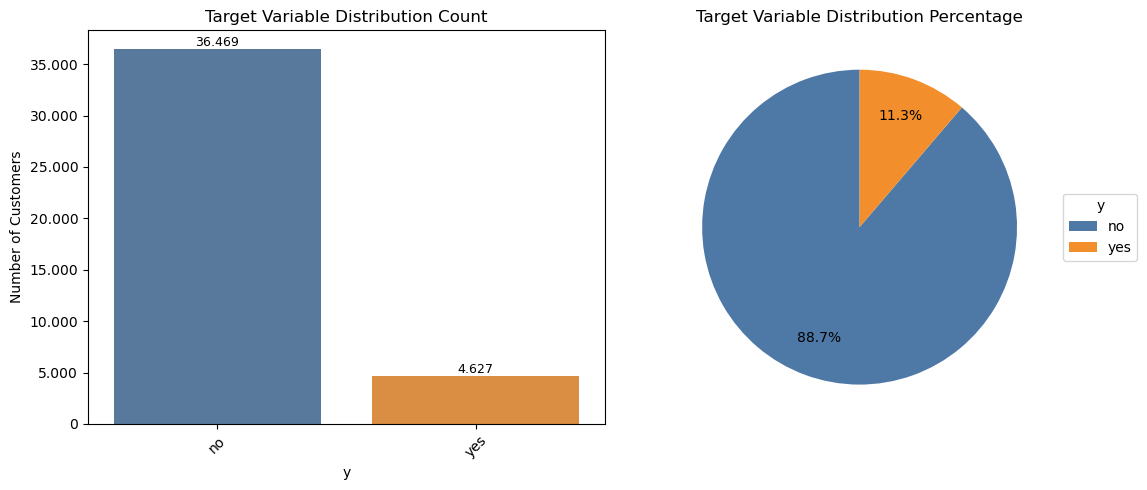

In [22]:
plot_categorical_univariate(df, "y", order=["no", "yes"], title="Target Variable")

### **Insight**

The target is highly imbalanced: only **11.26%** of customers subscribed to a term deposit, while **88.74%** did not. This shows that successful conversion is rare and the campaign has a low success rate.

Therefore, further EDA is needed to identify which customer profiles, campaign factors, previous campaign history, and economic indicators are related to subscription behavior.

Because the business objective is to find potential subscribers, the model should not rely on accuracy. Evaluation should prioritize **Recall** and **F3-score**, supported by **PR-AUC**, **ROC-AUC**, and **Confusion Matrix**.


### 1.1.2 Job Distribution

This visualization shows the distribution of customers based on their job category.

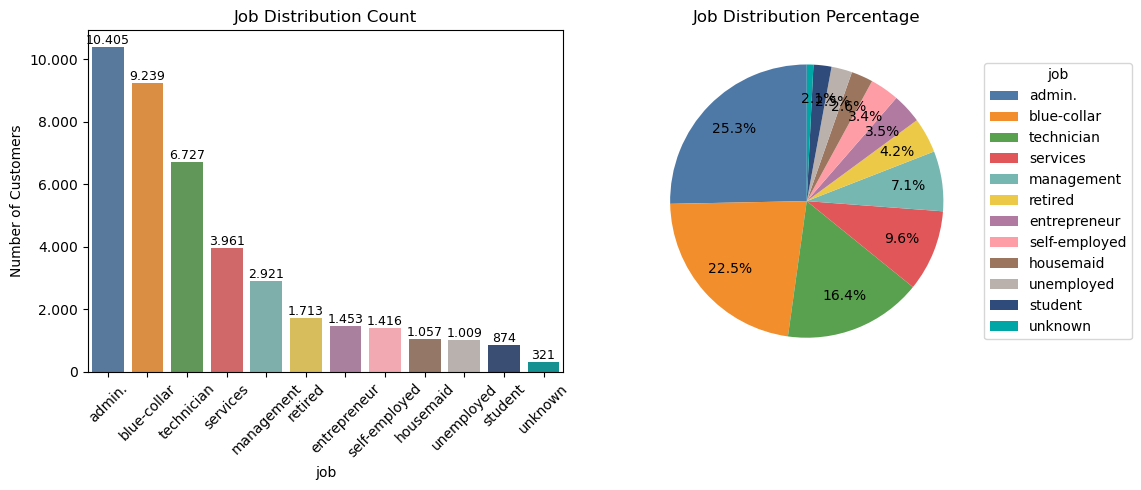

In [23]:
plot_categorical_univariate(df, "job", title="Job")

**Insight:** The campaign audience is dominated by `admin.`, `blue-collar`, and `technician` customers. These job groups represent the largest reachable market, but they still need further analysis to identify which segment has stronger subscription potential.

#### 1.1.3 Marital Status Distribution

This visualization shows the distribution of customers based on their marital status.

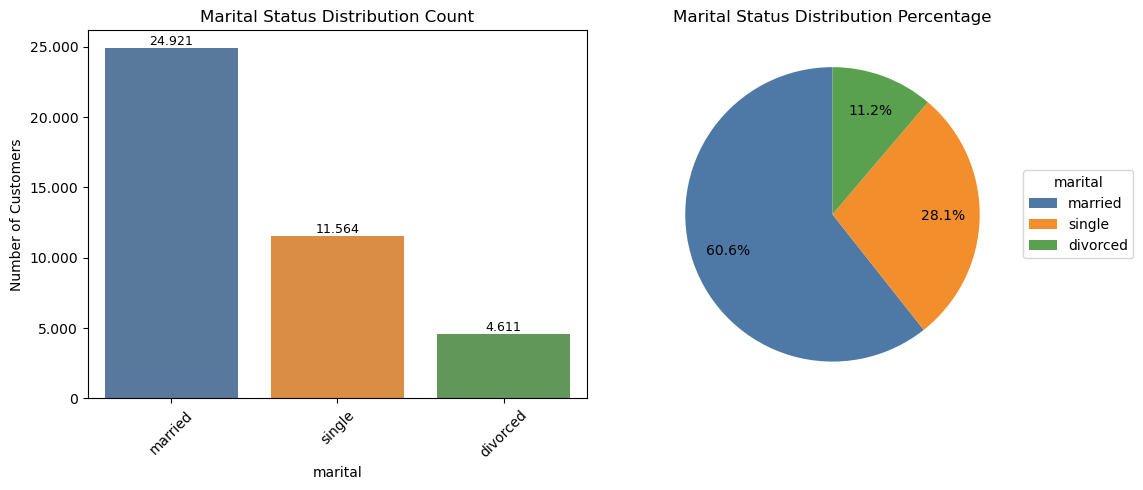

In [24]:
plot_categorical_univariate(df, "marital", title="Marital Status")

**Insight:** Most contacted customers are `married`, indicating that the campaign mainly reached financially mature customers. This segment may be important for term deposit offers because they are more likely to have stable financial planning needs.

#### 1.1.4 Education Distribution

This visualization shows the distribution of customers based on their education level.

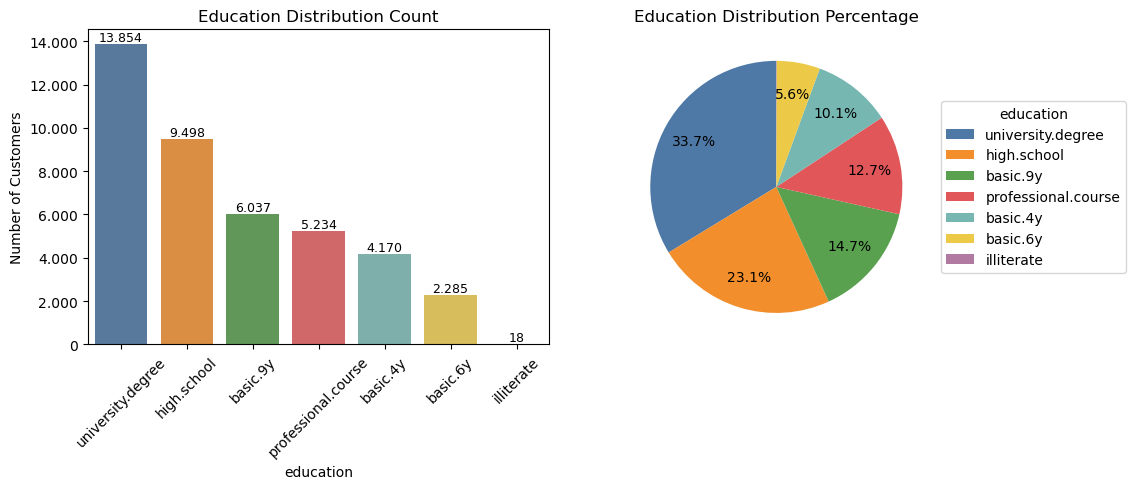

In [25]:
plot_categorical_univariate(df, "education", title="Education")

**Insight:** Most customers come from `university.degree`, `high.school`, and `basic.9y` education levels. This shows that the campaign covers broad education segments, so marketing messages may need to be adjusted based on customer financial literacy.

#### 1.1.5 Credit Default Distribution

This visualization shows the distribution of customers based on their credit default status.

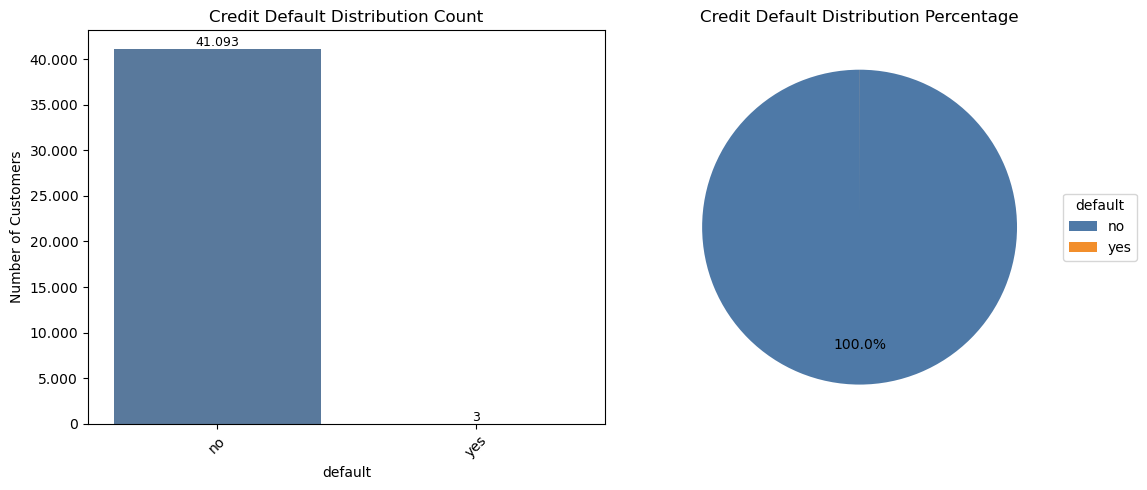

In [26]:
plot_categorical_univariate(df, "default", title="Credit Default")

**Insight:** Almost all customers have no credit default, meaning the campaign mostly targeted customers with healthier credit profiles. This is useful because term deposit offers are more relevant for customers with better financial stability.

#### 1.1.6 Housing Loan Distribution

This visualization shows the distribution of customers based on whether they have a housing loan.

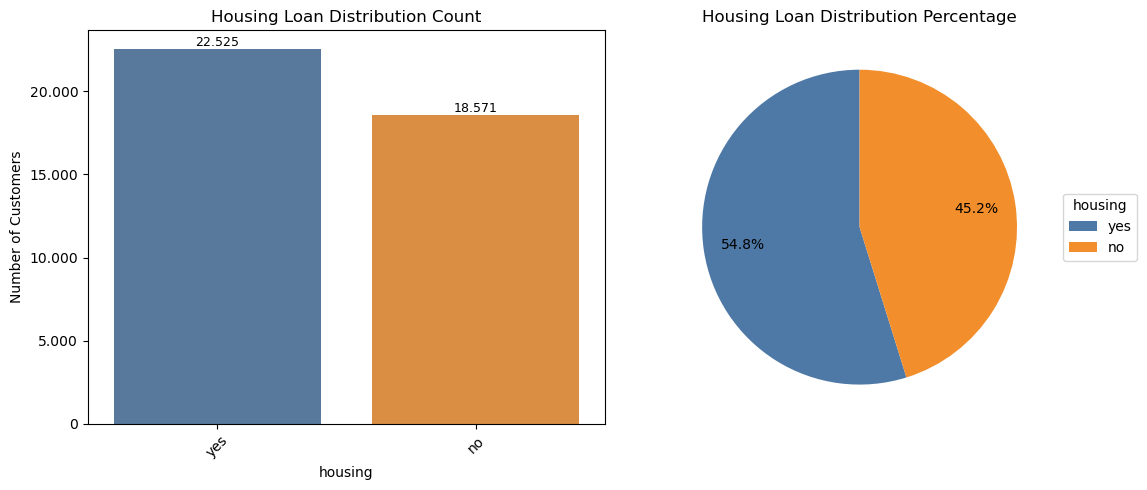

In [27]:
plot_categorical_univariate(df, "housing", title="Housing Loan")

**Insight:** Housing loan ownership is relatively balanced, meaning the campaign reached both customers with and without long-term financial commitments. This feature may help distinguish customer financial capacity in further analysis.

#### 1.1.7 Personal Loan Distribution

This visualization shows the distribution of customers based on whether they have a personal loan.

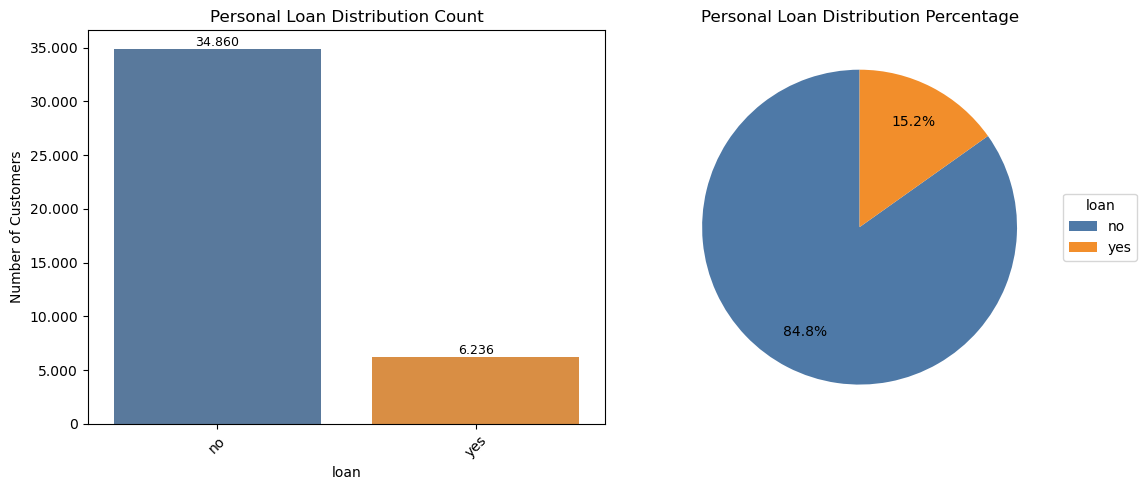

In [28]:
plot_categorical_univariate(df, "loan", title="Personal Loan")

**Insight:** Most customers do not have a personal loan, suggesting that many contacted customers may have lower short-term debt burden. This group could be more suitable for savings-based products such as term deposits.

#### 1.1.8 Contact Method Distribution

This visualization shows the distribution of customers based on the communication channel used during the campaign.

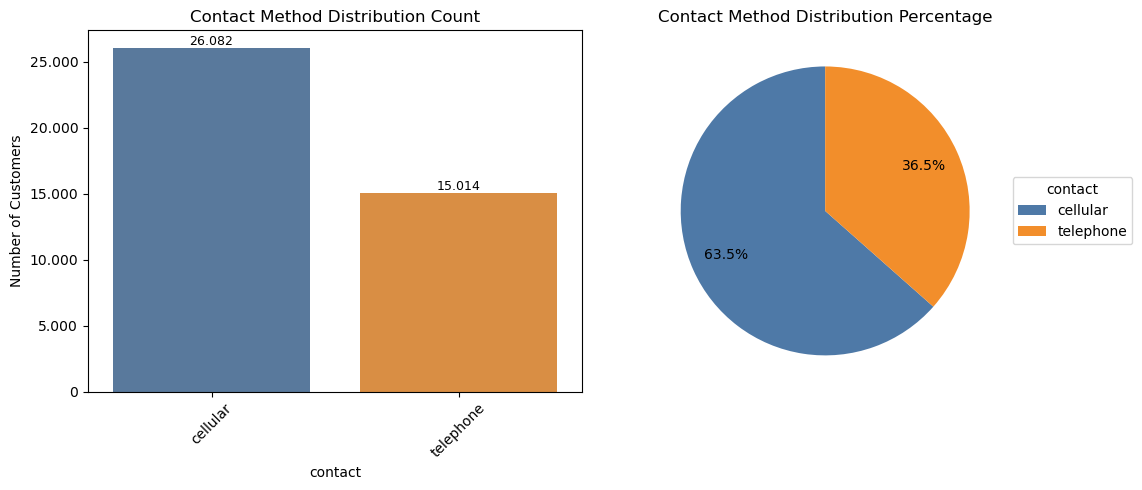

In [29]:
plot_categorical_univariate(df, "contact", title="Contact Method")

**Insight:** Most customers were contacted through `cellular`, showing that mobile contact is the main communication channel. This channel should be prioritized further if it also shows stronger conversion in bivariate analysis.

#### 1.1.9 Campaign Month Distribution

This visualization shows the distribution of customers based on the month when they were contacted.

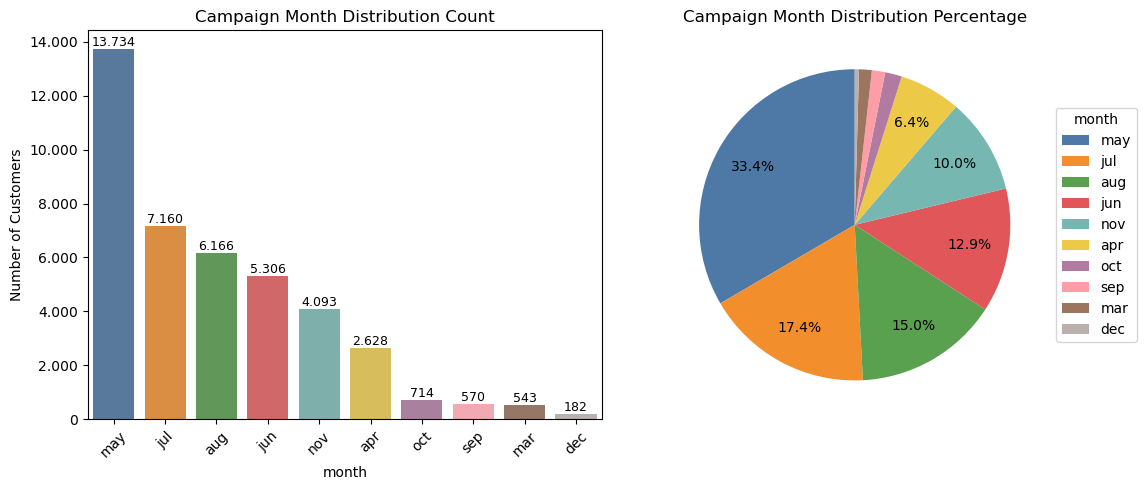

In [30]:
plot_categorical_univariate(df, "month", title="Campaign Month")

**Insight:** Campaign activity is concentrated in specific months, especially May, July, August, and June. This indicates that campaign timing is not evenly distributed, so the bank should evaluate which months generate better subscription outcomes.

#### 1.1.10 Day of Week Distribution

This visualization shows the distribution of customers based on the day of the week when they were contacted.

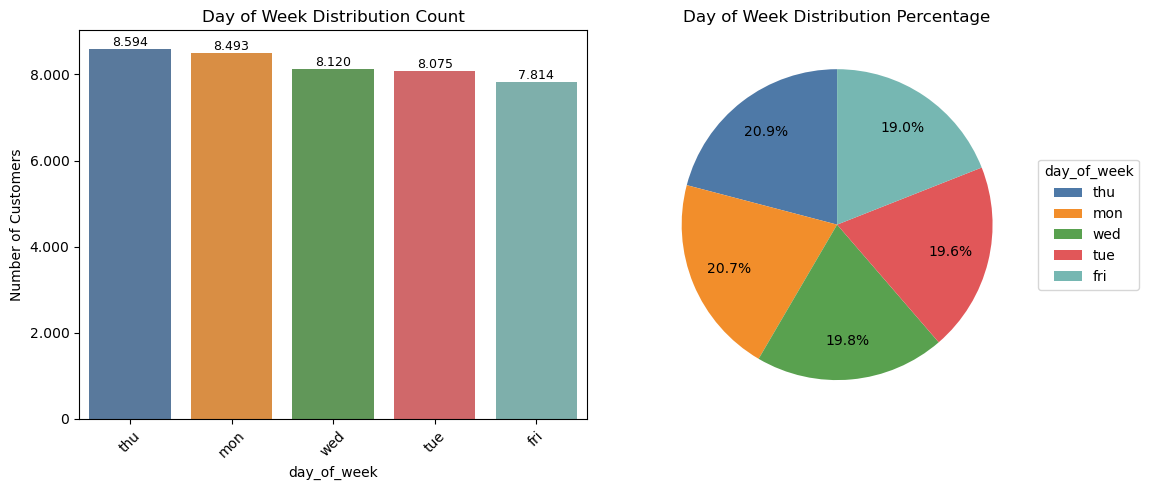

In [31]:
plot_categorical_univariate(df, "day_of_week", title="Day of Week")

**Insight:** Customer contacts are relatively balanced across weekdays. This suggests that campaign day may not be the main driver of targeting strategy compared to customer profile, channel, or campaign timing.

#### 1.1.11 Previous Campaign Outcome Distribution

This visualization shows the distribution of customers based on the result of the previous marketing campaign.

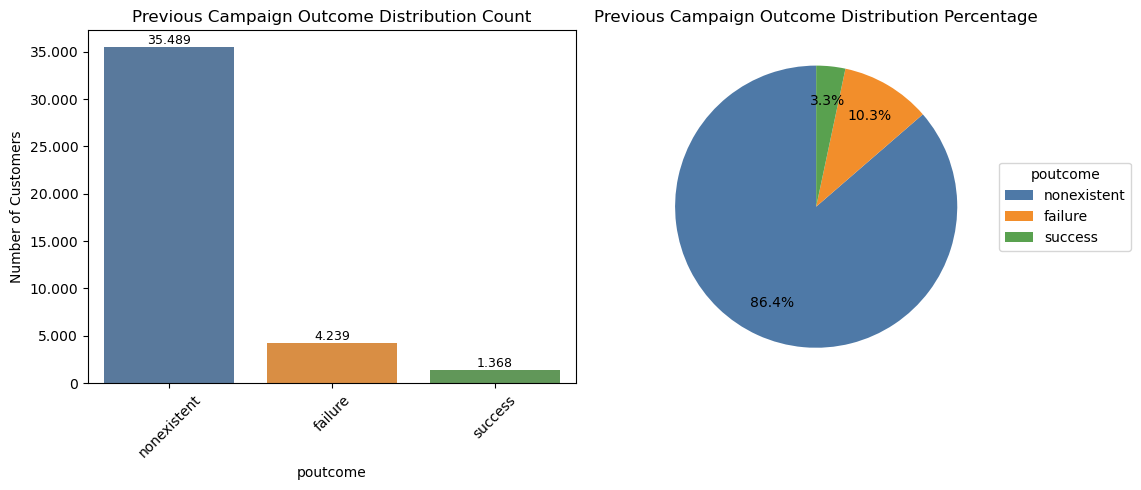

In [32]:
plot_categorical_univariate(df, "poutcome", title="Previous Campaign Outcome")

**Insight:** Most customers have `nonexistent` previous campaign outcomes, meaning many were not clearly reached in past campaigns. However, customers with previous outcomes may provide stronger signals for future campaign prioritization.

### Categorical Univariate Analysis Summary

**Insight** : The categorical distribution shows that the bank’s campaign mainly reached large working customer segments, married customers, cellular contacts, and specific campaign months. This means the campaign was not randomly distributed, but concentrated on certain customer profiles and campaign periods.

However, distribution alone only shows where the campaign effort was spent, not where the campaign was most effective. The key business question is whether these dominant segments actually produce higher subscription rates. Therefore, the next step is to perform bivariate analysis to identify which customer groups, contact methods, and campaign timings should be prioritized to improve campaign efficiency and conversion.


### 1.2 Numerical Feature Distribution

This analysis visualizes the distribution of numerical features to understand their spread, skewness, and potential outliers. Histogram is used to observe the distribution shape, while boxplot is used to detect possible outliers.

##### Visualization Function for Numerical Features

This function helps analyze numerical variables by showing their distribution using a histogram and potential outliers using a boxplot.

In [33]:
# Visualization Function for Numerical Features
def format_thousand_dot(x, pos=None):
    return f"{int(x):,}".replace(",", ".")

def plot_numerical_univariate(df, column, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram: distribution
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[0],
        color="#3274A1"
    )

    axes[0].set_title(f"{title or column} Distribution")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")
    axes[0].yaxis.set_major_formatter(FuncFormatter(format_thousand_dot))

    # Boxplot: outlier check
    sns.boxplot(
        data=df,
        x=column,
        ax=axes[1],
        color="#9ECAE1"
    )

    axes[1].set_title(f"{title or column} Boxplot")
    axes[1].set_xlabel(column)

    plt.tight_layout()
    plt.show()

#### 1.2.1 Age Distribution

This visualization shows the distribution of customer age and potential extreme age values.

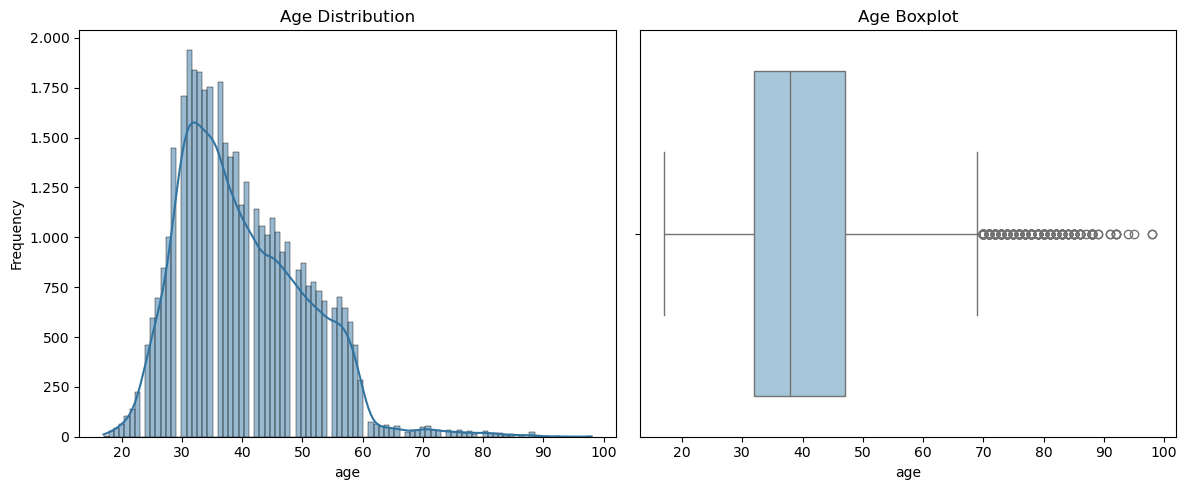

In [34]:
plot_numerical_univariate(df, "age", title="Age")

**Insight:** Most customers are in productive working age, showing that the campaign mainly targets economically active customers. This group is relevant for term deposit offers because they are more likely to have income and saving potential.

#### 1.2.2 Call Duration Distribution

This visualization shows the distribution of call duration during the campaign.

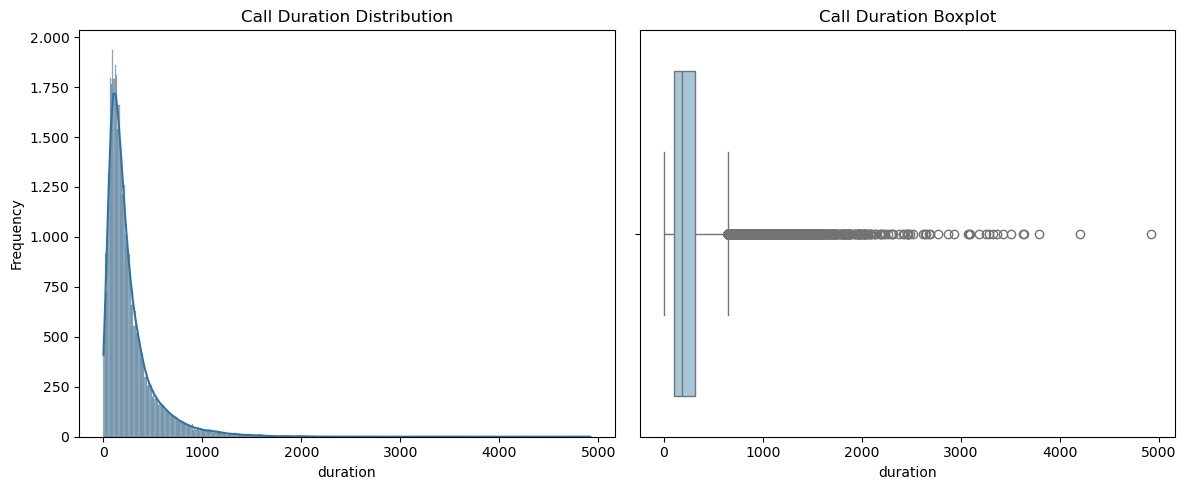

In [35]:
plot_numerical_univariate(df, "duration", title="Call Duration")

**Insight:** Most calls are short, while only a few calls last much longer. Longer calls may indicate stronger customer interest, but `duration` should not be used in modeling because it is only known after the call and can cause data leakage.

#### 1.2.3 Campaign Contact Frequency Distribution

This visualization shows how many times customers were contacted during the current campaign.

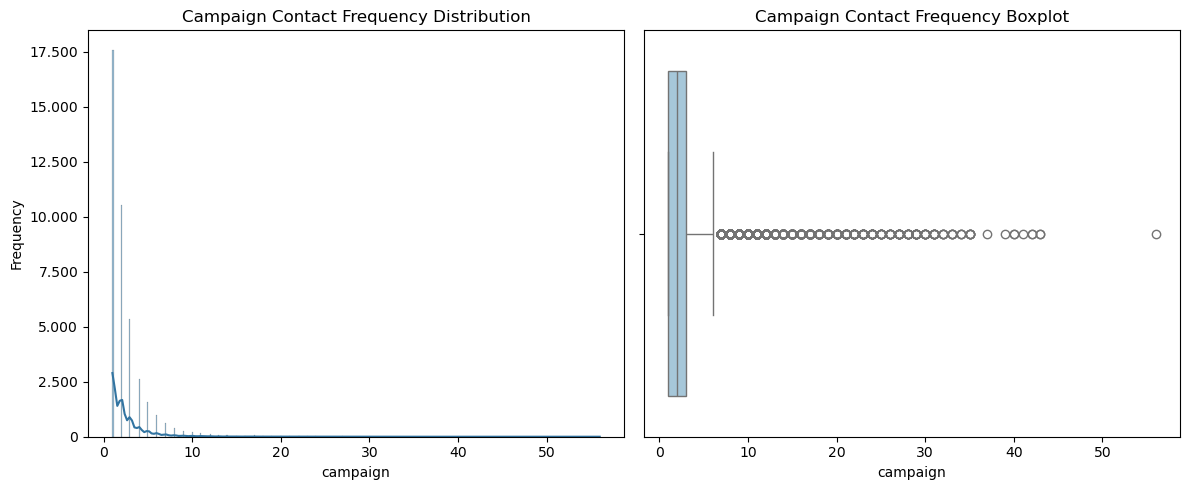

In [36]:
plot_numerical_univariate(df, "campaign", title="Campaign Contact Frequency")

**Insight:** Most customers were contacted only a few times, but some received repeated contacts. This suggests that excessive contact may occur, so the bank should optimize contact frequency to avoid wasting agent effort.

#### 1.2.4 Days Since Previous Contact Distribution

This visualization shows the number of days since customers were last contacted in a previous campaign.

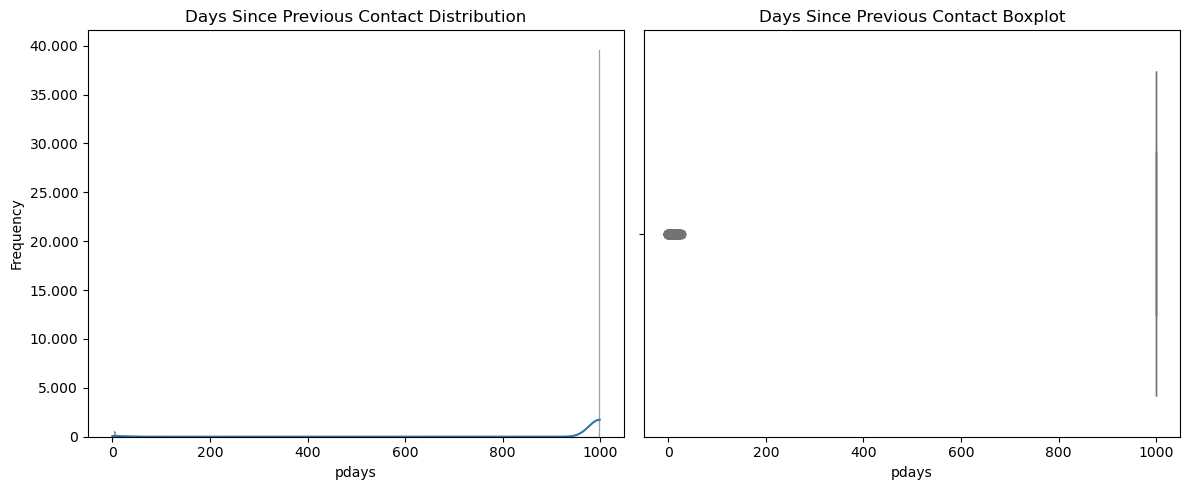

In [37]:
plot_numerical_univariate(df, "pdays", title="Days Since Previous Contact")

**Insight:** Many customers have `pdays = 999`, meaning they were not contacted in a previous campaign. This value is not a real number of days, so it needs special treatment before modeling.

#### 1.2.5 Previous Contacts Distribution

This visualization shows the number of previous contacts before the current campaign.

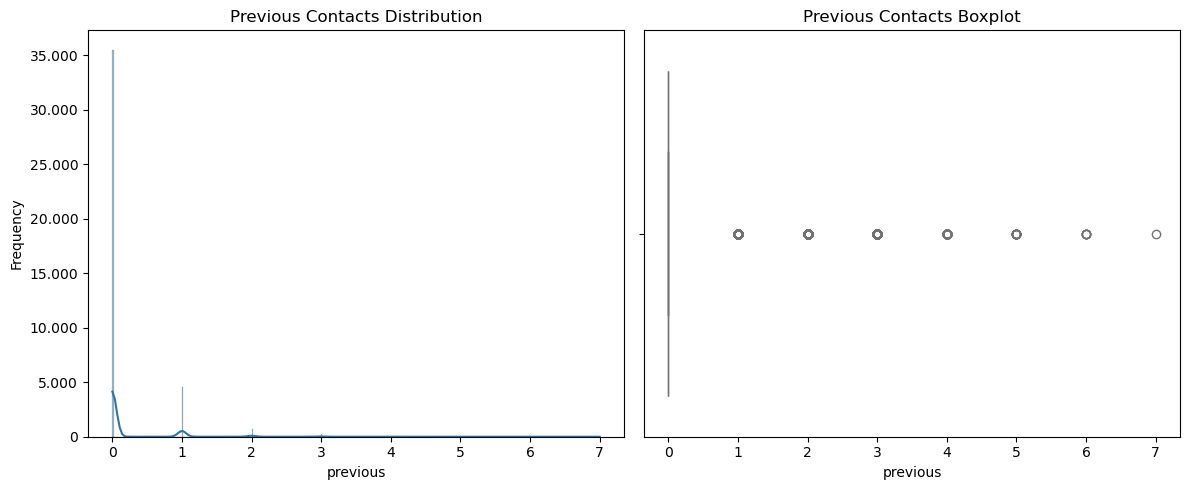

In [38]:
plot_numerical_univariate(df, "previous", title="Previous Contacts")

**Insight:** Most customers had little or no previous campaign contact. This shows that previous engagement is limited, but customers with prior contact history may still provide useful signals for campaign targeting.

#### 1.2.6 Employment Variation Rate Distribution

This visualization shows the distribution of employment variation rate as an economic indicator.

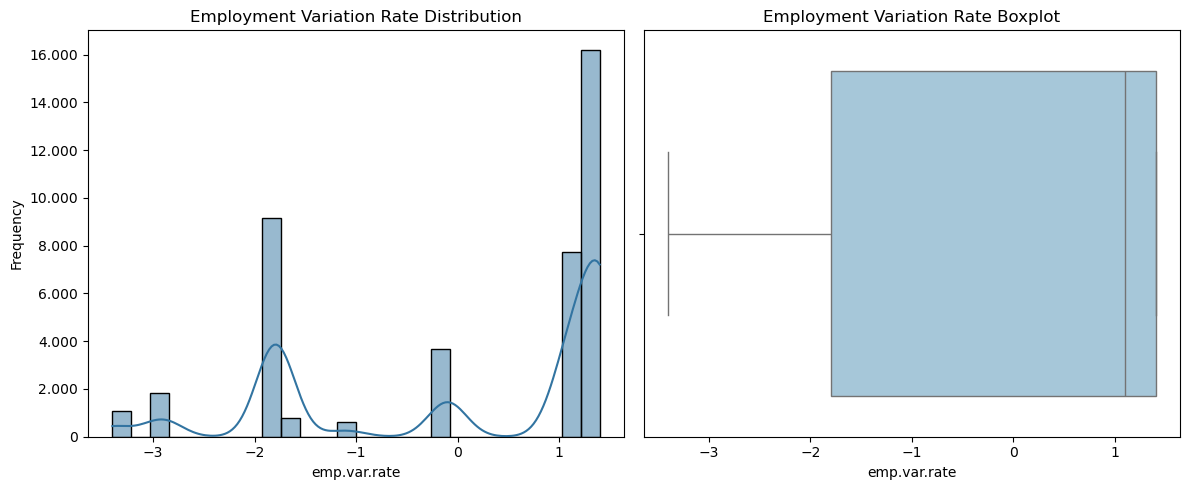

In [39]:
plot_numerical_univariate(df, "emp.var.rate", title="Employment Variation Rate")

**Insight:** Employment variation rate appears in grouped values because it reflects economic conditions, not individual behavior. This feature can help capture whether labor market conditions influence customer willingness to subscribe.

#### 1.2.7 Consumer Price Index Distribution

This visualization shows the distribution of consumer price index values.

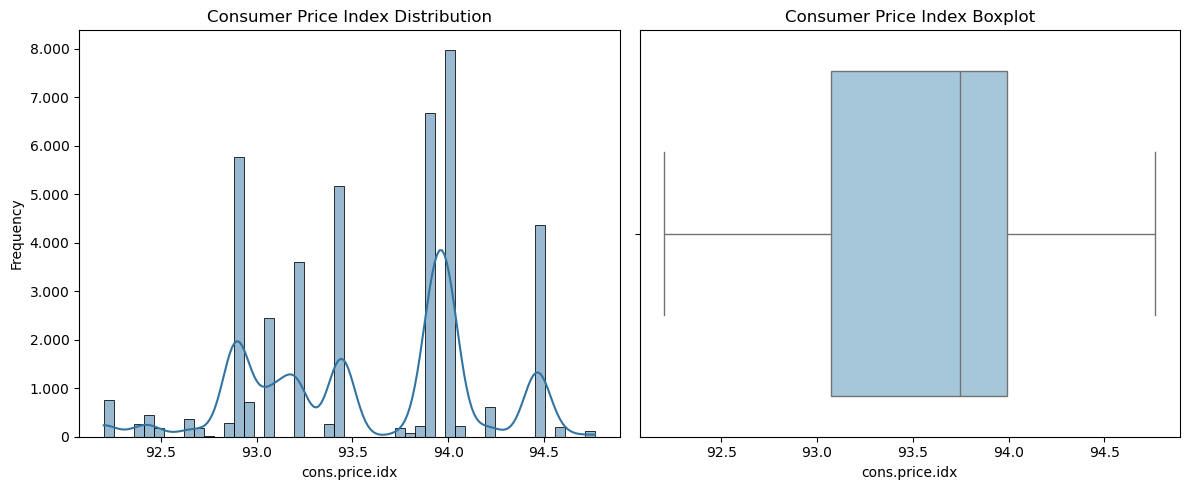

In [40]:
plot_numerical_univariate(df, "cons.price.idx", title="Consumer Price Index")

**Insight:** Consumer price index has limited variation because it represents macroeconomic conditions during the campaign. It may still help explain customer saving decisions under different price or inflation environments.

#### 1.2.8 Consumer Confidence Index Distribution

This visualization shows the distribution of consumer confidence index values.

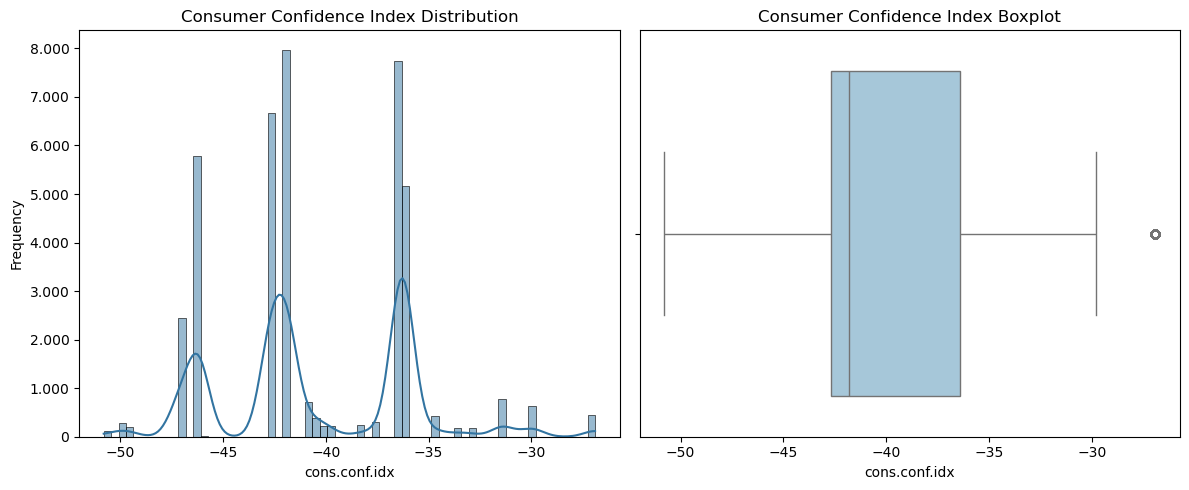

In [41]:
plot_numerical_univariate(df, "cons.conf.idx", title="Consumer Confidence Index")

**Insight:** Consumer confidence index reflects customer sentiment toward the economy. This is relevant because customers may be more or less willing to place money in term deposits depending on their confidence level.

#### 1.2.9 Euribor 3 Month Rate Distribution

This visualization shows the distribution of Euribor 3-month rate as an economic indicator.

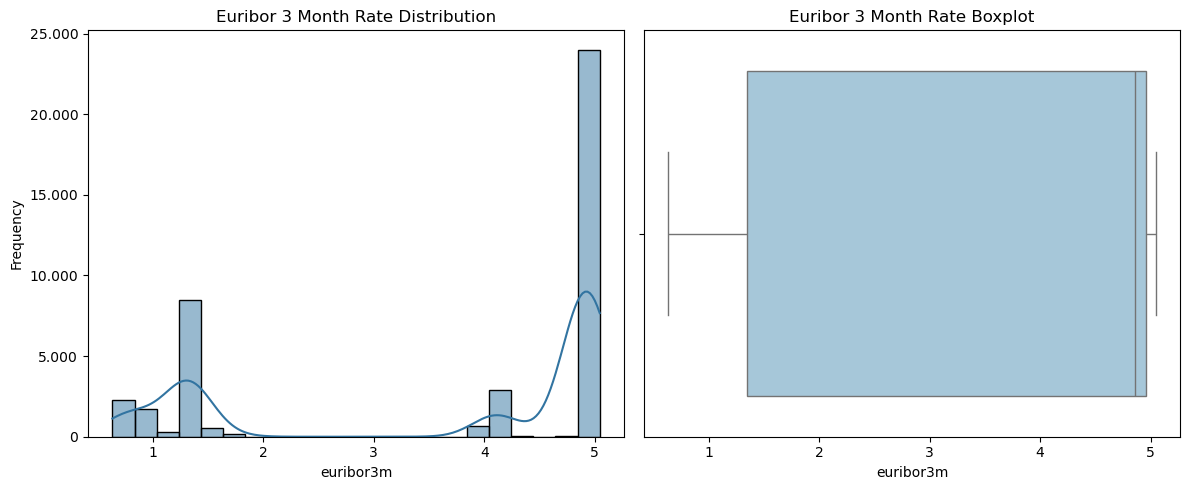

In [42]:
plot_numerical_univariate(df, "euribor3m", title="Euribor 3 Month Rate")

**Insight:** Euribor 3-month rate shows different interest-rate environments during the campaign. This feature is important because term deposit attractiveness can change when market interest rates change. 

#### 1.2.10 Number of Employees Distribution

This visualization shows the distribution of the number of employees as a macroeconomic indicator.

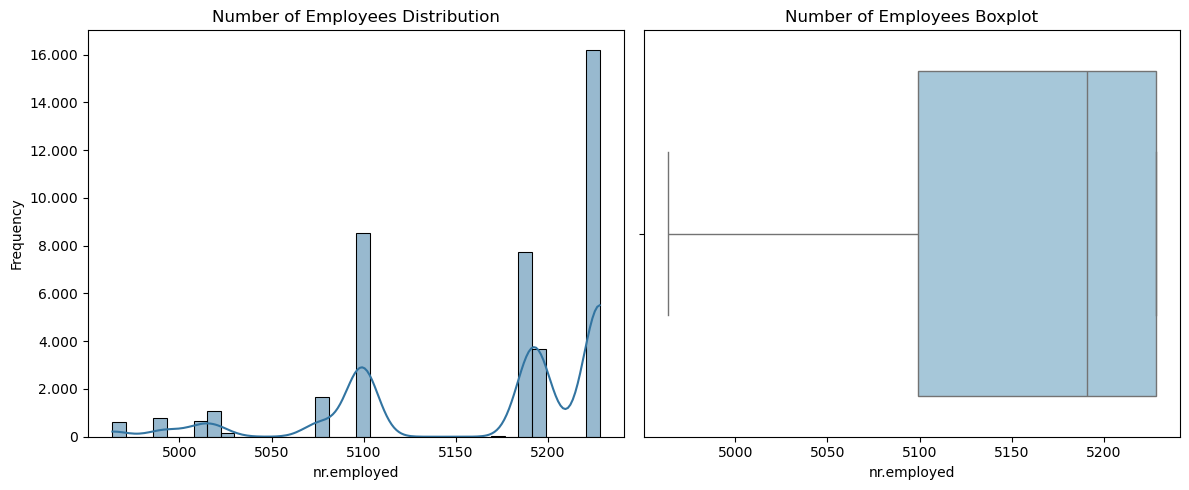

In [43]:
plot_numerical_univariate(df, "nr.employed", title="Number of Employees")

**Insight:** Number of employees represents macroeconomic employment conditions. This feature may help the model understand whether broader labor market conditions affect customer subscription behavior.

### Numerical Univariate Analysis Summary 
**Insight:** Overall, the numerical features show that the campaign mainly reached productive-age customers with low campaign interaction intensity. Most customers had short calls, few contacts, and limited previous campaign history, indicating that the bank needs a more targeted approach to identify customers with stronger subscription potential.

In addition, macroeconomic features such as `euribor3m`, `emp.var.rate`, and `nr.employed` suggest that customer decisions may also be influenced by economic conditions. Therefore, the model should not only rely on customer profile, but also consider campaign behavior and economic signals to improve term deposit targeting.

## **2. Bivariate Analysis**

Bivariate analysis is conducted to examine the relationship between each feature and the target variable `y`. The analysis is divided into categorical features and numerical features to make the interpretation clearer.

### 2.1 Categorical Features vs Target

This section analyzes the relationship between categorical features and term deposit subscription. Each categorical feature is compared with the target variable to identify which customer groups have higher subscription tendencies.

In [44]:
# Function for categorical feature vs target

def format_thousand_dot(x, pos=None):
    return f"{int(x):,}".replace(",", ".")

def plot_categorical_vs_target(feature_name, feature_label, figsize=(12, 5)):
    summary = pd.crosstab(df[feature_name], df["y"])

    if "no" not in summary.columns:
        summary["no"] = 0
    if "yes" not in summary.columns:
        summary["yes"] = 0

    summary = summary[["no", "yes"]]

    summary["total_customer"] = summary["no"] + summary["yes"]
    summary["subscription_rate_%"] = (
        summary["yes"] / summary["total_customer"] * 100
    ).round(2)

    # Sort by highest number of subscribed customers
    summary = summary.sort_values("yes", ascending=False)

    order = summary.index.tolist()
    baseline_rate = (df["y"].eq("yes").mean() * 100).round(2)

    # Prepare count data for vertical bar chart
    count_df = summary[["no", "yes"]].reset_index()
    count_df = count_df.melt(
        id_vars=feature_name,
        value_vars=["no", "yes"],
        var_name="Subscription",
        value_name="Count"
    )

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # =========================
    # LEFT: Vertical count bar
    # =========================
    ax1 = sns.barplot(
        data=count_df,
        x=feature_name,
        y="Count",
        hue="Subscription",
        order=order,
        hue_order=["no", "yes"],
        palette=["#B7D3EA", "#1F5A8A"],
        ax=axes[0]
    )

    for container in ax1.containers:
        ax1.bar_label(
            container,
            labels=[
                f"{int(bar.get_height()):,}".replace(",", ".")
                if bar.get_height() > 0 else ""
                for bar in container
            ],
            padding=3,
            fontsize=8
        )

    axes[0].yaxis.set_major_formatter(FuncFormatter(format_thousand_dot))
    axes[0].set_title(f"{feature_label} Distribution by Target", fontsize=13, fontweight="bold")
    axes[0].set_xlabel(feature_label)
    axes[0].set_ylabel("Number of Customers")
    axes[0].legend(title="Subscription")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_ylim(0, count_df["Count"].max() * 1.15)

    # =========================
    # RIGHT: Horizontal subscription rate bar
    # =========================
    rate = summary["subscription_rate_%"]

    ax2 = sns.barplot(
        x=rate.values,
        y=rate.index,
        hue=rate.index,
        palette="Blues_r",
        legend=False,
        ax=axes[1]
    )

    for i, value in enumerate(rate.values):
        ax2.text(
            value + 0.2,
            i,
            f"{value:.1f}%",
            va="center",
            fontsize=9
        )

    ax2.axvline(
        baseline_rate,
        color="#D62728",
        linestyle="--",
        linewidth=1.8,
        label=f"Overall Rate ({baseline_rate:.2f}%)"
    )

    axes[1].set_title(f"Subscription Rate by {feature_label}", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Subscription Rate (%)")
    axes[1].set_ylabel(feature_label)
    axes[1].set_xlim(0, max(rate.max() * 1.25, baseline_rate * 1.5))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

#### 2.1.1 Job vs Term Deposit Subscription

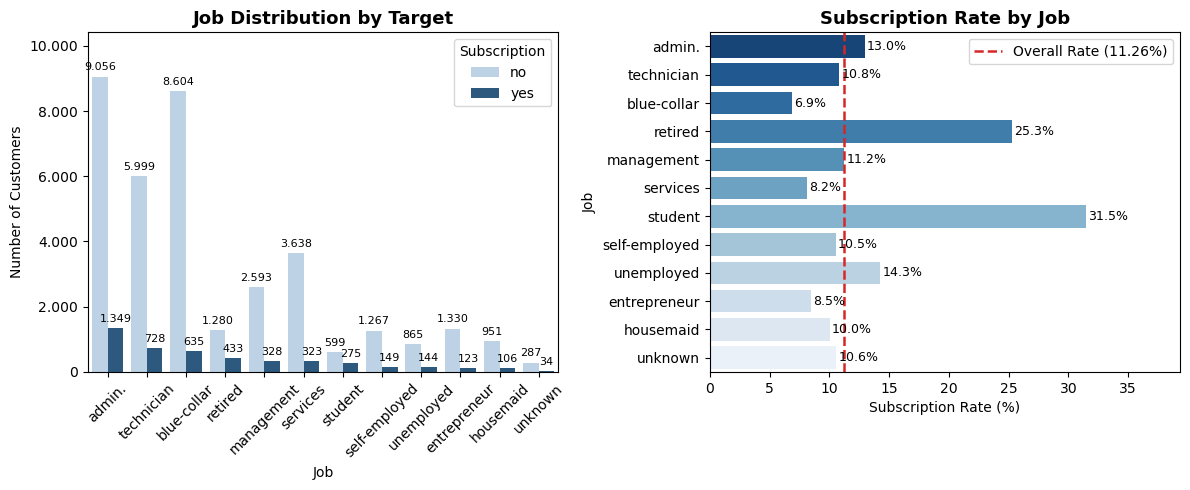

In [45]:
# Job vs Term Deposit Subscription

plot_categorical_vs_target("job", "Job")

### **Insight**

`student` and `retired` show the highest subscription rates, while larger groups like `admin.` and `blue-collar` have lower conversion.

This means the bank should not only target the largest job groups, but prioritize job segments with higher subscription potential to improve campaign efficiency.

#### 2.1.2 Marital Status vs Term Deposit Subscription

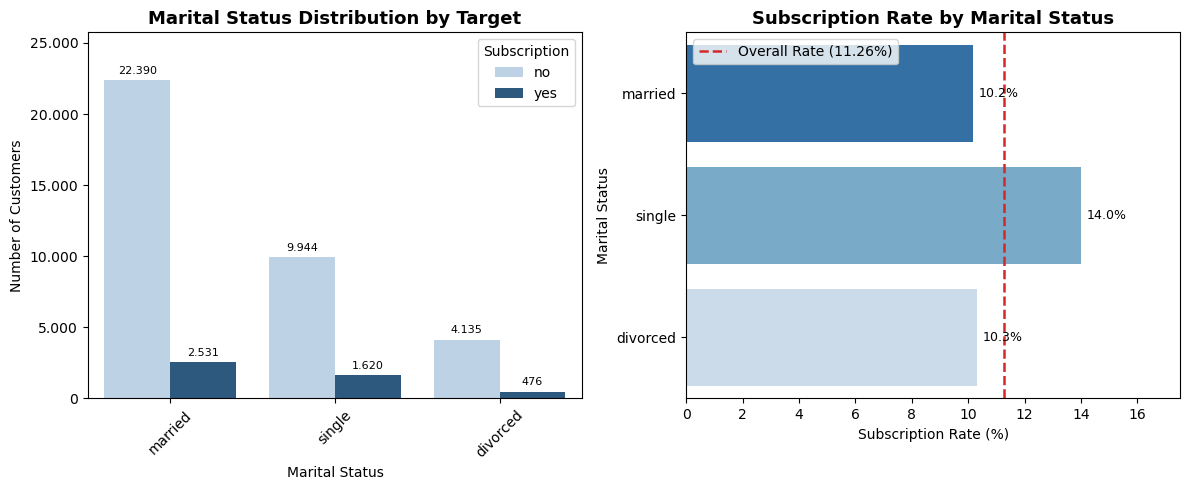

In [46]:
# Marital Status vs Term Deposit Subscription

plot_categorical_vs_target("marital", "Marital Status")

### **Insight**

`single` customers show the strongest subscription tendency compared to other marital groups.

This suggests that marital status can be used as a segmentation signal, where the bank can prioritize more responsive customer groups instead of treating all marital segments equally.

#### 2.1.3 Education vs Term Deposit Subscription

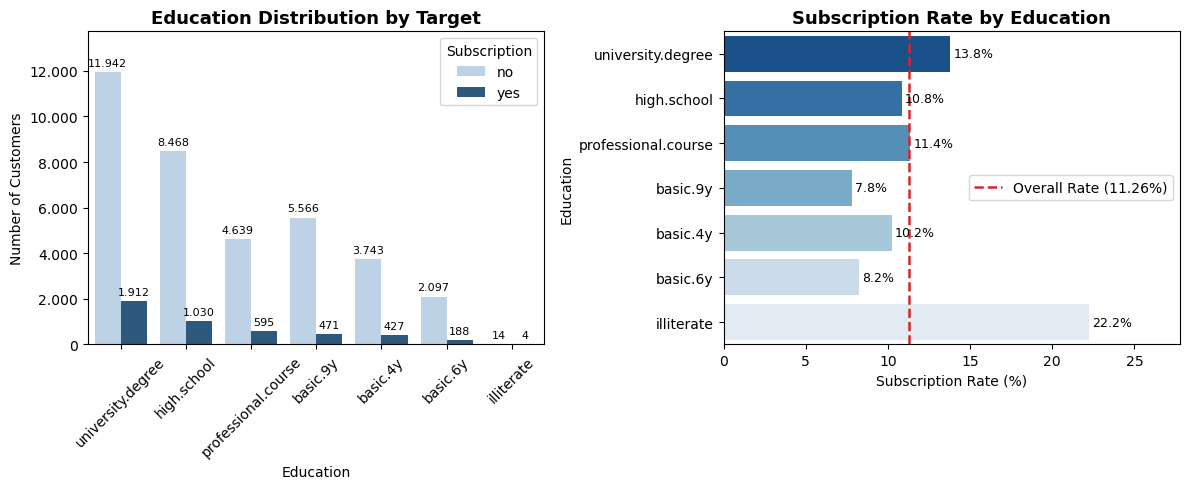

In [47]:
# Education vs Term Deposit Subscription

plot_categorical_vs_target("education", "Education")

### **Insight**

Education shows that high subscription rate alone is not enough for prioritization. Although `illiterate` has the highest rate, its customer volume is very small, so the business impact is limited.

`university.degree` is more valuable for targeting because it combines a relatively strong subscription rate with a large customer base.

This means the bank should prioritize segments with both good conversion potential and sufficient customer volume to improve campaign impact.

#### 2.1.4 Default vs Term Deposit Subscription

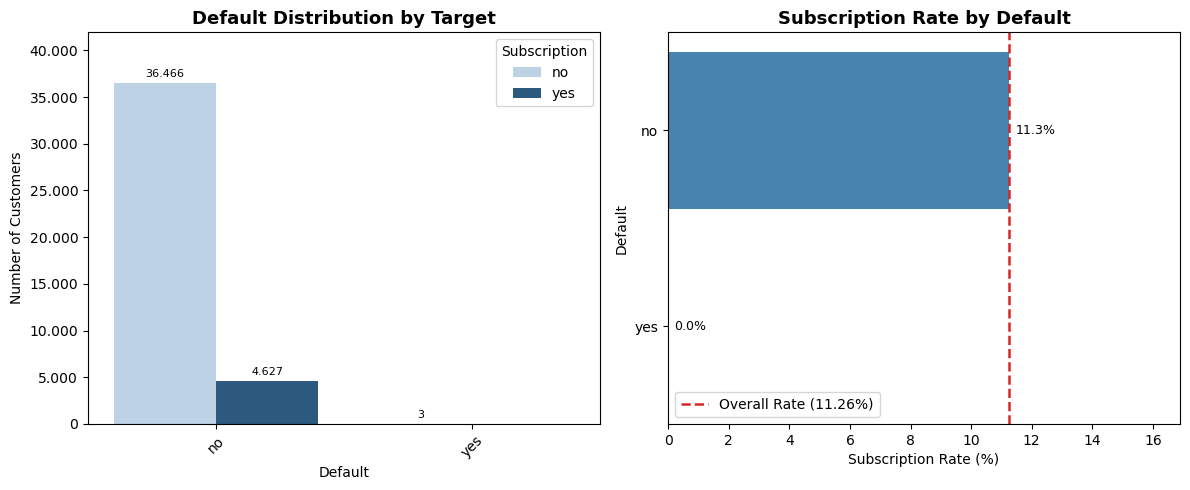

In [48]:
# Default vs Term Deposit Subscription

plot_categorical_vs_target("default", "Default")

### **Insight**

`default` has very low variation because almost all customers are in the `no` group.

This means `default` is not strong enough as a main targeting factor, so the bank should rely more on stronger features such as job, education, contact type, month, and previous campaign outcome.

#### 2.1.5 Housing Loan vs Term Deposit Subscription

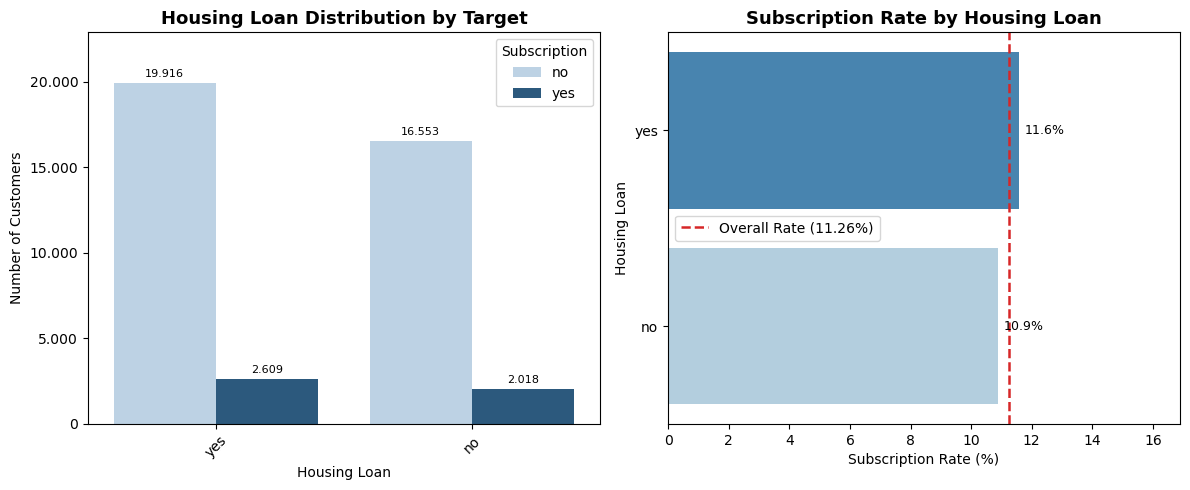

In [49]:
# Housing Loan vs Term Deposit Subscription

plot_categorical_vs_target("housing", "Housing Loan")

### **Insight**

Housing loan status shows only a small difference in subscription rate, so it is not strong enough to be used as a main targeting factor. This feature is better used as supporting information together with stronger customer attributes.

#### 2.1.6 Personal Loan vs Term Deposit Subscription

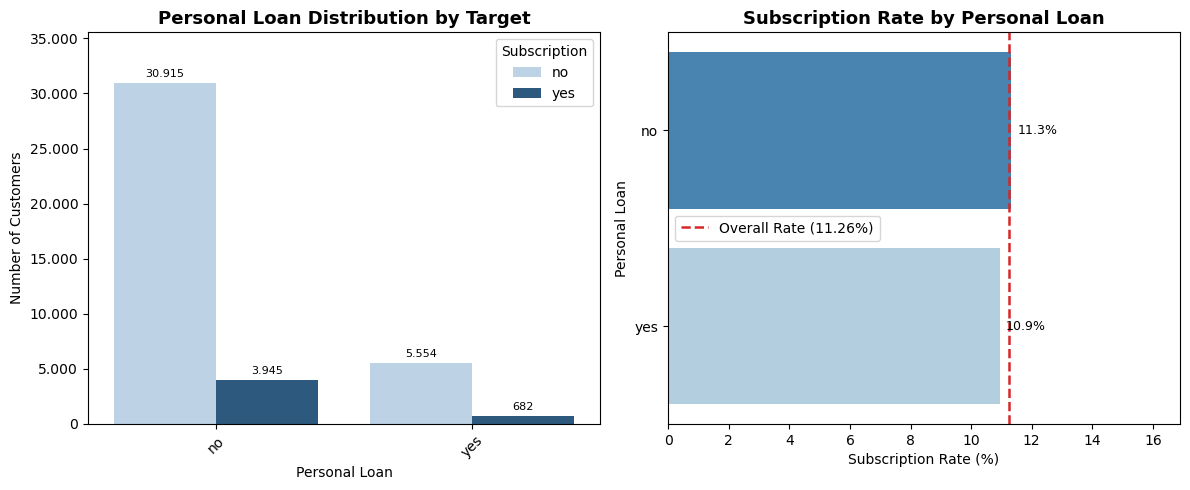

In [50]:
# Personal Loan vs Term Deposit Subscription

plot_categorical_vs_target("loan", "Personal Loan")

### **Insight**

Personal loan status shows almost no meaningful difference in subscription rate, indicating that this feature has limited value for prioritizing customers in the campaign.


#### 2.1.7 Contact Type vs Term Deposit Subscription

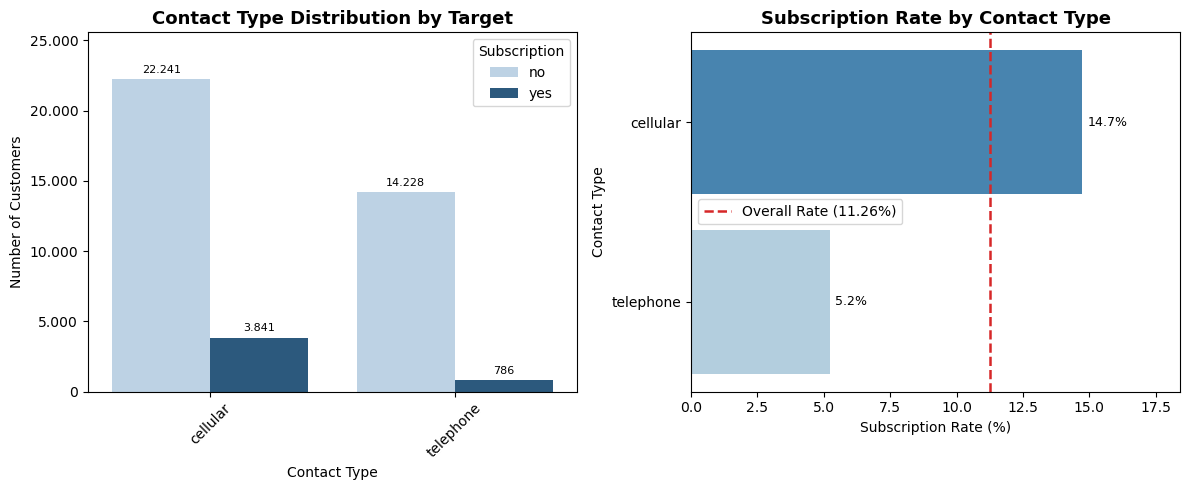

In [51]:
# Contact Type vs Term Deposit Subscription

plot_categorical_vs_target("contact", "Contact Type")

### **Insight**

`cellular` contact has a much higher subscription rate than telephone, showing that cellular communication is a more effective channel for reaching potential subscribers.

#### 2.1.8 Month vs Term Deposit Subscription

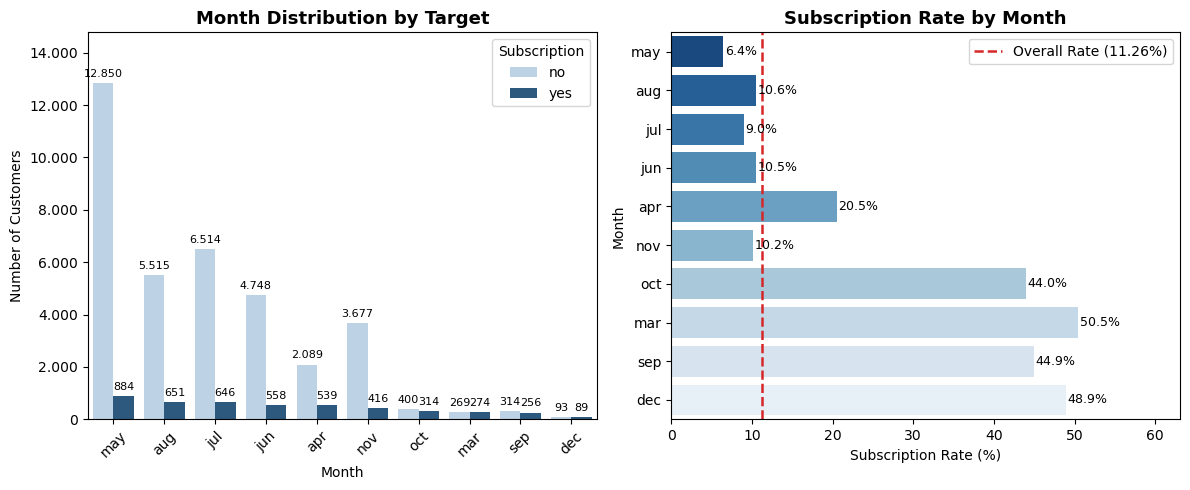

In [52]:
# Month vs Term Deposit Subscription

plot_categorical_vs_target("month", "Month")

### **Insight**

Campaign month has a strong relationship with subscription rate, especially in `mar`, `dec`, `sep`, and `oct`. This suggests that campaign timing should be considered to improve telemarketing effectiveness.

#### 2.1.9 Day of Week vs Term Deposit Subscription

This analysis compares campaign contact day with term deposit subscription to identify whether the day of contact is related to subscription tendency.

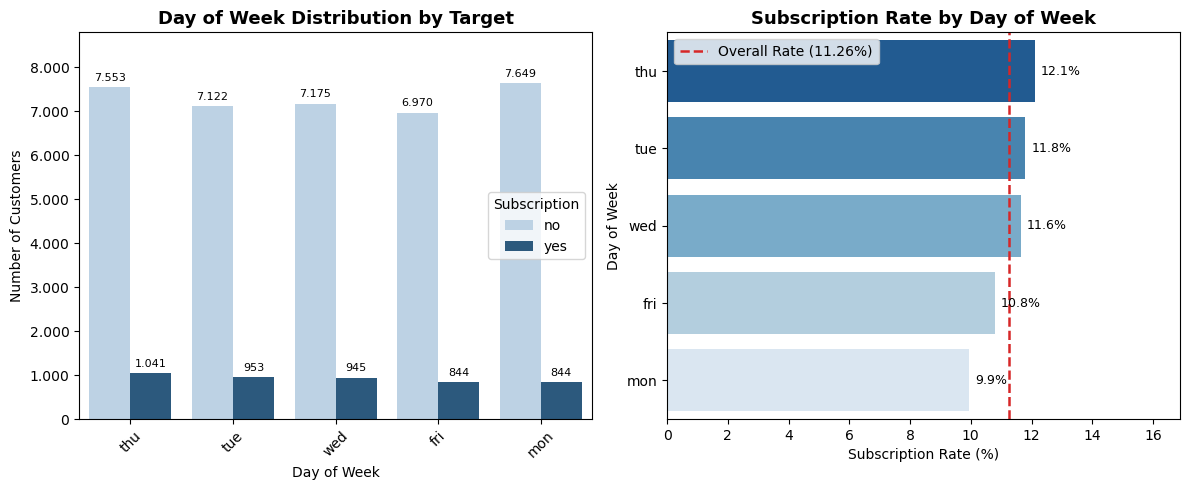

In [53]:
# Day of Week vs Term Deposit Subscription

plot_categorical_vs_target("day_of_week", "Day of Week")

### **Insight**

Subscription rates across weekdays are relatively similar, meaning day of week is not a strong factor for campaign prioritization.


#### 2.1.10 Previous Campaign Outcome vs Term Deposit Subscription

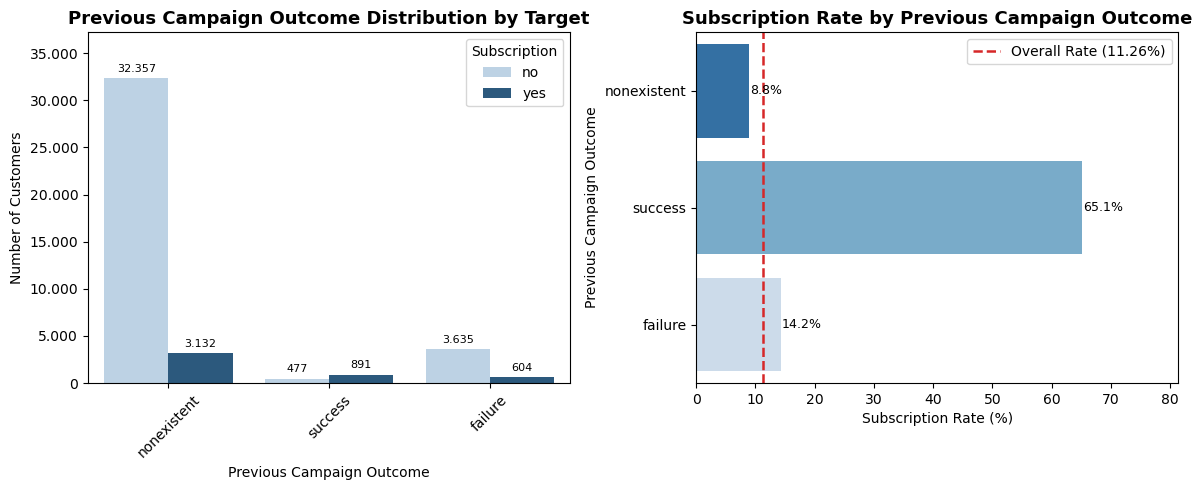

In [54]:
# Previous Campaign Outcome vs Term Deposit Subscription

plot_categorical_vs_target("poutcome", "Previous Campaign Outcome")

### **Insight**

Customers with a previous campaign outcome of `success` have the highest subscription rate. This makes previous campaign outcome one of the strongest signals for identifying customers with higher subscription potential.


### **2.2 Numerical Features vs Target**

This section analyzes the relationship between numerical features and the target variable `y`. The purpose is to understand how customer characteristics, campaign activity, previous campaign history, and economic indicators differ between customers who subscribed and did not subscribe to a term deposit.

Numerical features will be analyzed separately against the target to identify patterns that may help explain subscription behavior and support customer prioritization.


In [55]:
# Function for numerical feature vs target

def format_thousand_dot(x, pos=None):
    return f"{int(x):,}".replace(",", ".")

def plot_numerical_vs_target(feature_name, feature_label, bins=5, figsize=(14, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # =========================
    # Boxplot by target
    # =========================
    sns.boxplot(
        data=df,
        x="y",
        y=feature_name,
        hue="y",
        order=["no", "yes"],
        palette={"no": "#B7D3EA", "yes": "#1F5A8A"},
        ax=axes[0],
        legend=False
    )

    axes[0].set_title(f"{feature_label} Distribution by Target")
    axes[0].set_xlabel("Term Deposit Subscription")
    axes[0].set_ylabel(feature_label)

    # =========================
    # Binning: subscription rate by feature group
    # =========================
    temp_df = df[[feature_name, "y"]].copy()
    temp_df["y_binary"] = temp_df["y"].map({"no": 0, "yes": 1})

    # Create bins based on data distribution
    temp_df["feature_bin"] = pd.qcut(
        temp_df[feature_name],
        q=bins,
        duplicates="drop"
    )

    bin_summary = (
        temp_df.groupby("feature_bin", observed=True)
        .agg(
            total_customer=("y_binary", "count"),
            subscription_rate=("y_binary", "mean")
        )
        .reset_index()
    )

    bin_summary["subscription_rate_%"] = bin_summary["subscription_rate"] * 100
    bin_summary["bin_label"] = bin_summary["feature_bin"].astype(str)

    baseline_rate = df["y"].eq("yes").mean() * 100

    ax2 = sns.barplot(
        data=bin_summary,
        x="bin_label",
        y="subscription_rate_%",
        color="#1F5A8A",
        ax=axes[1]
    )

    for i, value in enumerate(bin_summary["subscription_rate_%"]):
        ax2.text(
            i,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    axes[1].axhline(
        baseline_rate,
        color="#D62728",
        linestyle="--",
        linewidth=1.8,
        label=f"Overall Rate ({baseline_rate:.2f}%)"
    )

    axes[1].set_title(f"Subscription Rate by {feature_label} Group")
    axes[1].set_xlabel(f"{feature_label} Group")
    axes[1].set_ylabel("Subscription Rate (%)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_ylim(0, max(bin_summary["subscription_rate_%"].max() * 1.25, baseline_rate * 1.5))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

#### 2.2.1 Age vs Term Deposit Subscription

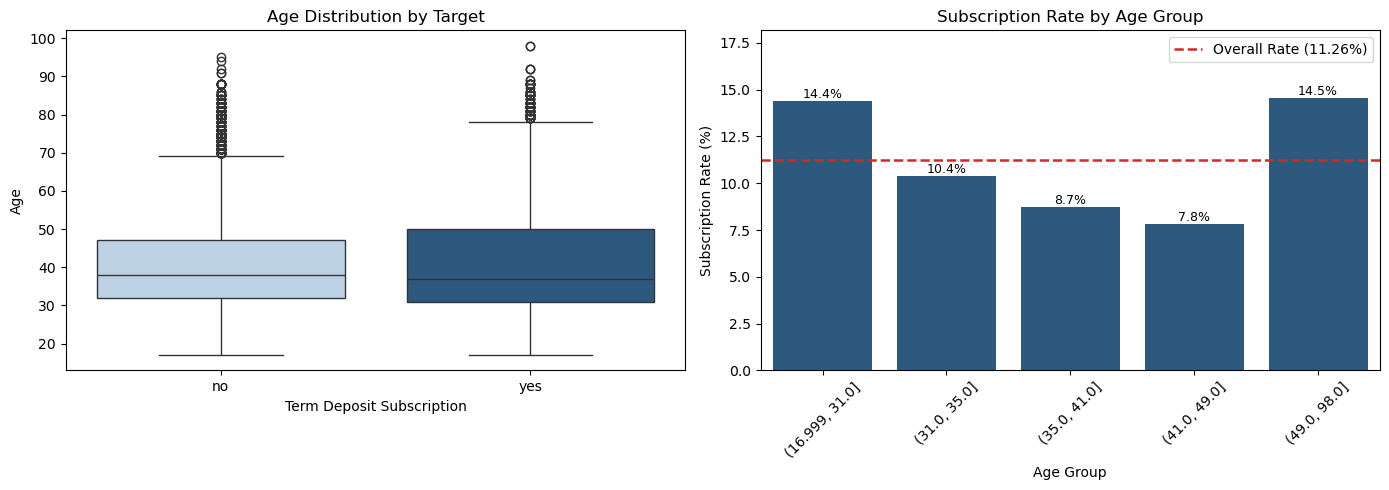

In [56]:
# Age vs Term Deposit Subscription

plot_numerical_vs_target("age", "Age")

### **Insight**

Age shows only a small difference between subscribed and non-subscribed customers. This means age alone is not a strong targeting factor and should be combined with other features for better customer prioritization.


#### 2.2.2 Duration vs Term Deposit Subscription

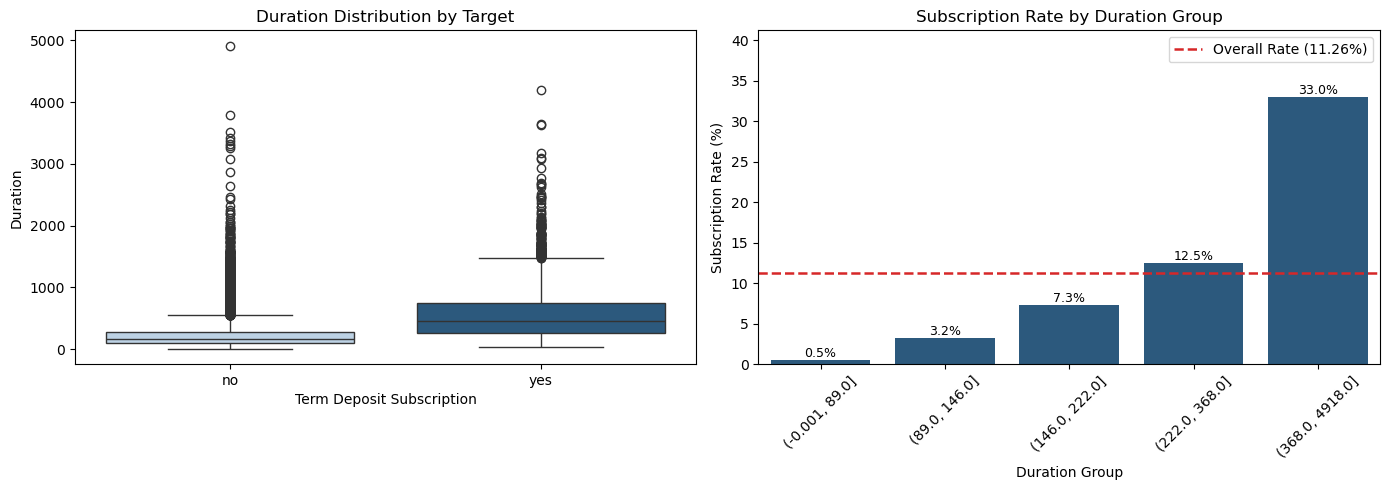

In [57]:
# Duration vs Term Deposit Subscription
plot_numerical_vs_target("duration", "Duration")

### **Insight**

Subscribed customers have much longer call duration than non-subscribed customers. This shows that longer conversations are strongly related to subscription, but `duration` should not be used for modeling because it causes data leakage.

#### 2.2.3 Campaign vs Term Deposit Subscription

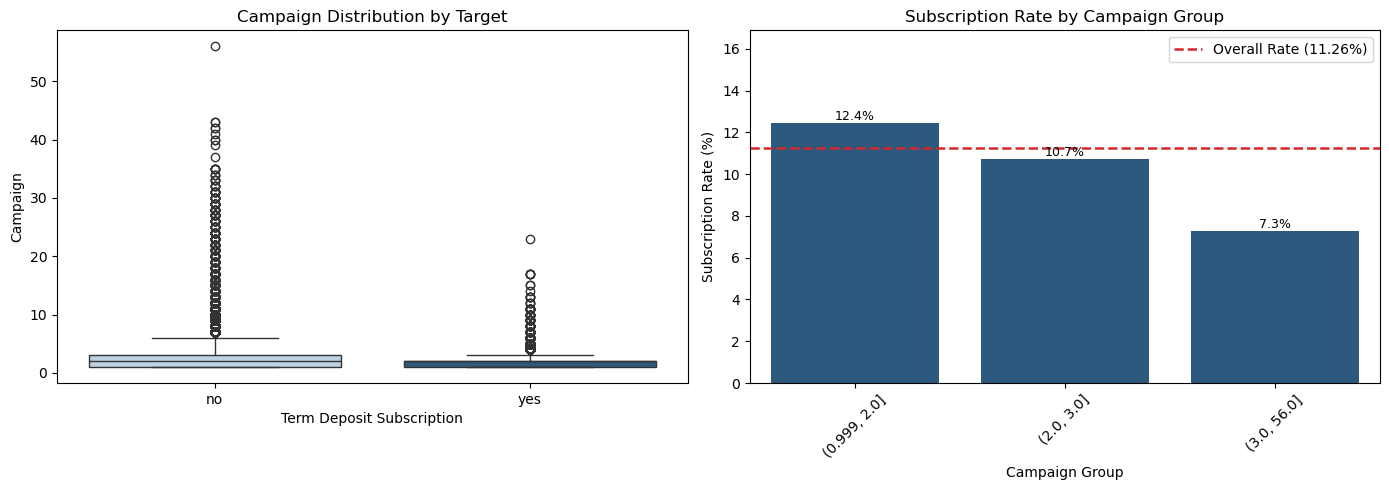

In [58]:
# Campaign vs Term Deposit Subscription
plot_numerical_vs_target("campaign", "Campaign")

### **Insight**

Both groups have the same median campaign contact, but non-subscribed customers show more extreme repeated contacts. This suggests that too many contact attempts do not guarantee conversion and may reduce campaign efficiency.

#### 2.2.4 Pdays vs Term Deposit Subscription

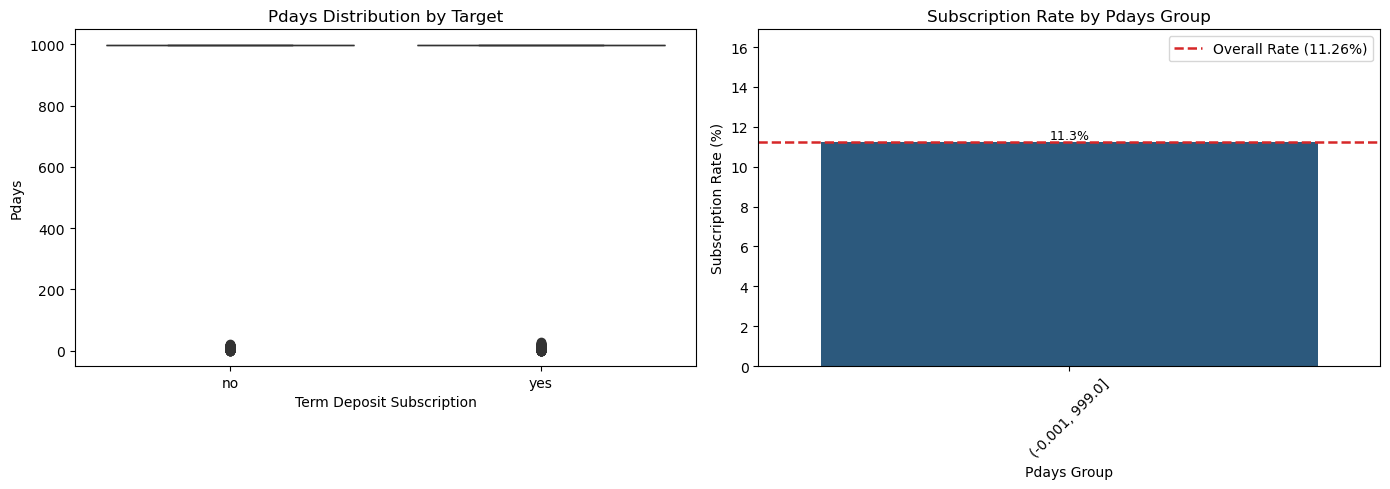

In [59]:
# Pdays vs Term Deposit Subscription
plot_numerical_vs_target("pdays", "Pdays")

### **Insight**

Both groups are dominated by `pdays = 999`, meaning most customers were not previously contacted. This feature should be handled carefully because `999` is a special value, not an actual number of days.

#### 2.2.5 Previous vs Term Deposit Subscription

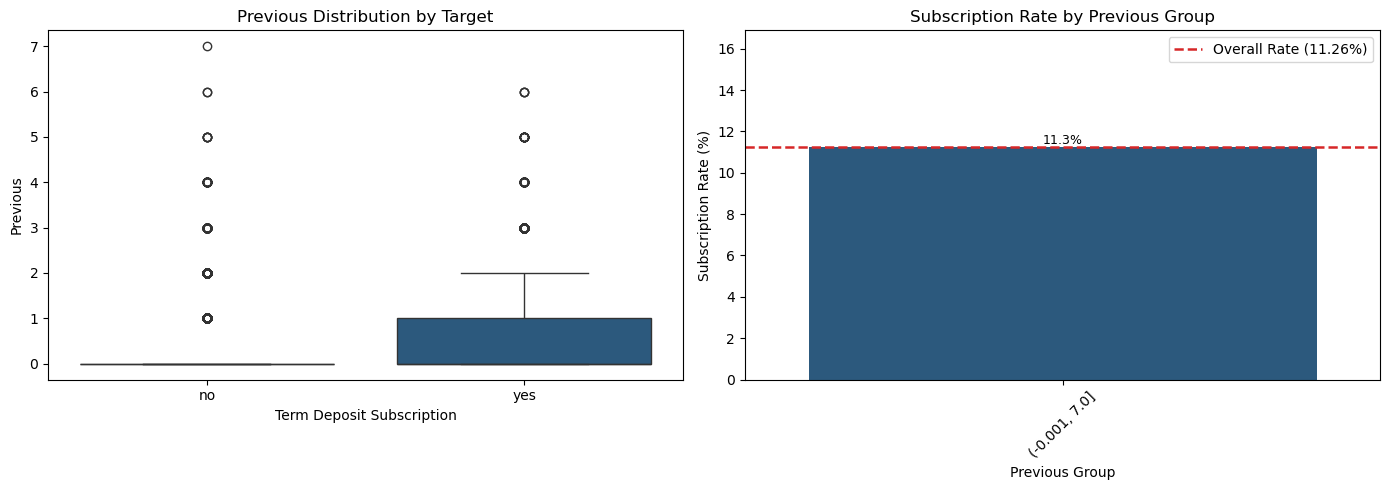

In [60]:
#2.2.5 Previous vs Term Deposit Subscription
plot_numerical_vs_target("previous", "Previous")

### **Insight**

Most customers have no previous campaign contact, but subscribed customers show a slightly wider previous-contact pattern. This suggests that previous campaign interaction can still provide useful signals when combined with `poutcome`.

#### 2.2.6 Employment Variation Rate vs Term Deposit Subscription

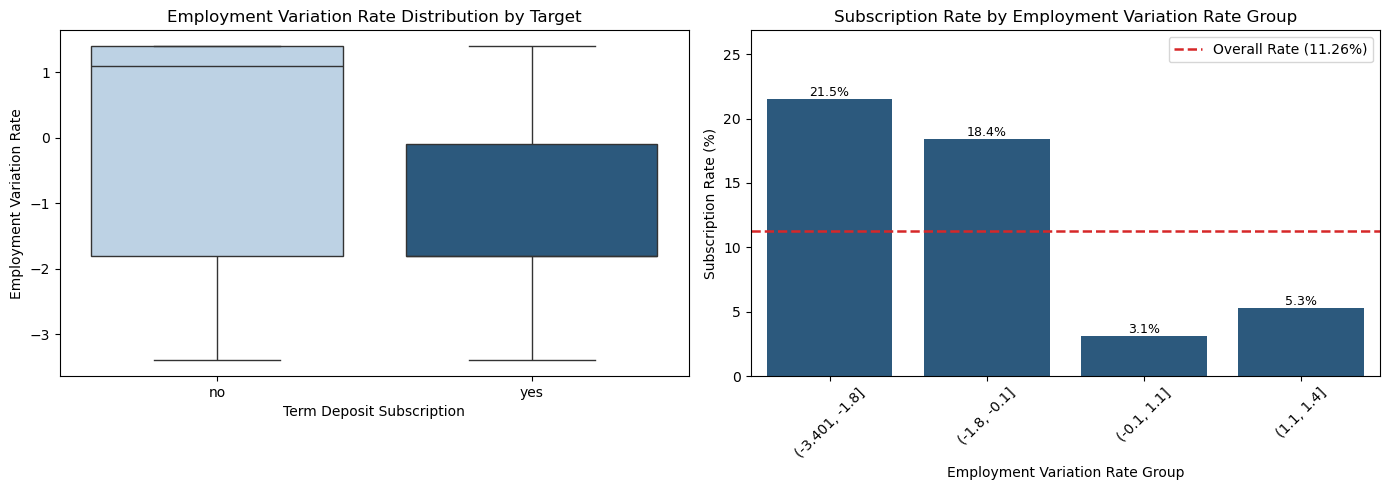

In [61]:
# Employment Variation Rate vs Term Deposit Subscription
plot_numerical_vs_target("emp.var.rate", "Employment Variation Rate")

### **Insight**

Subscribed customers tend to appear when employment variation rate is lower. This indicates that macroeconomic conditions affect campaign success and should be considered in campaign timing.

#### 2.2.7 Consumer Price Index vs Term Deposit Subscription

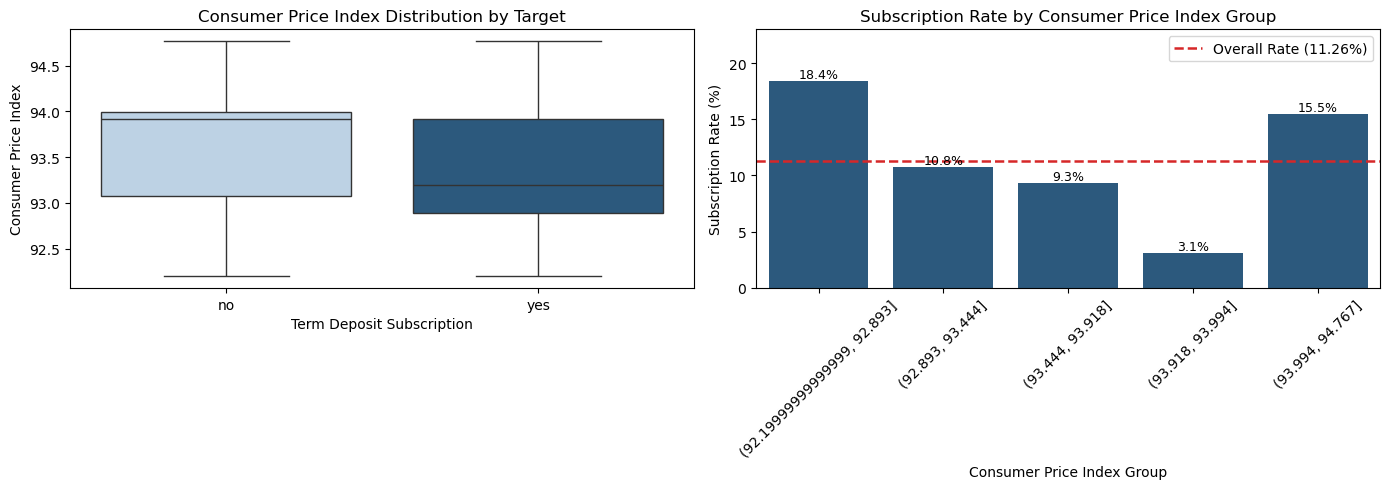

In [62]:
# Consumer Price Index vs Term Deposit Subscription

plot_numerical_vs_target("cons.price.idx", "Consumer Price Index")

### **Insight**

Subscribed customers tend to have a slightly lower consumer price index. This suggests that economic conditions can influence customer willingness to subscribe, although this feature should support—not replace—customer-level targeting.

#### 2.2.8 Consumer Confidence Index vs Term Deposit Subscription

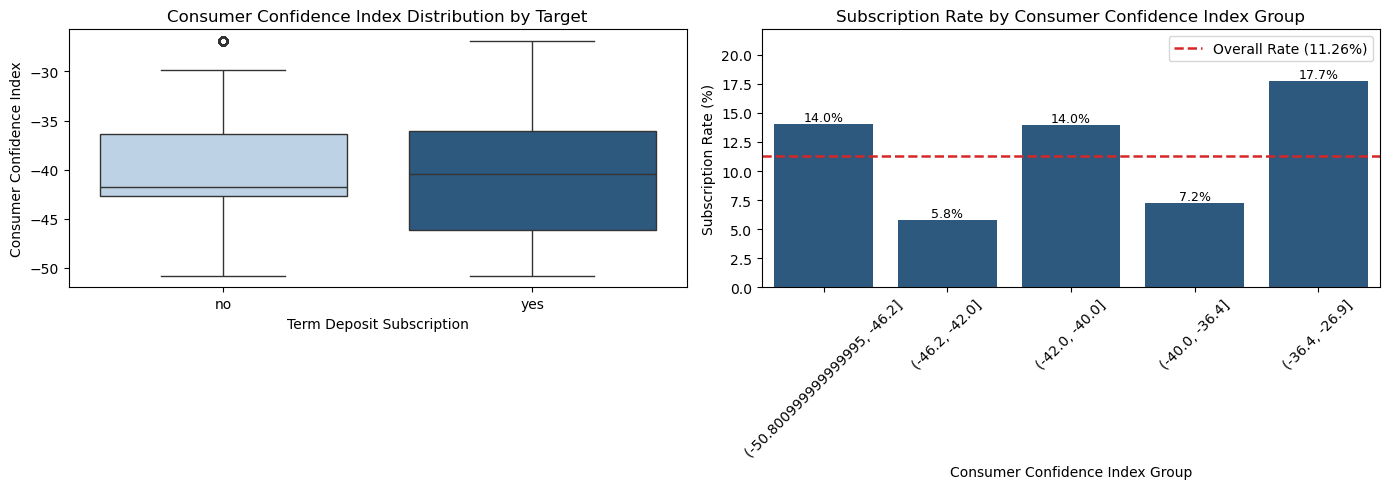

In [63]:
# Consumer Confidence Index vs Term Deposit Subscription
plot_numerical_vs_target("cons.conf.idx", "Consumer Confidence Index")

### **Insight**

Subscribed customers show slightly better consumer confidence values. This indicates that customer response may improve when confidence conditions are more favorable.

#### 2.2.9 Euribor 3 Month Rate vs Term Deposit Subscription

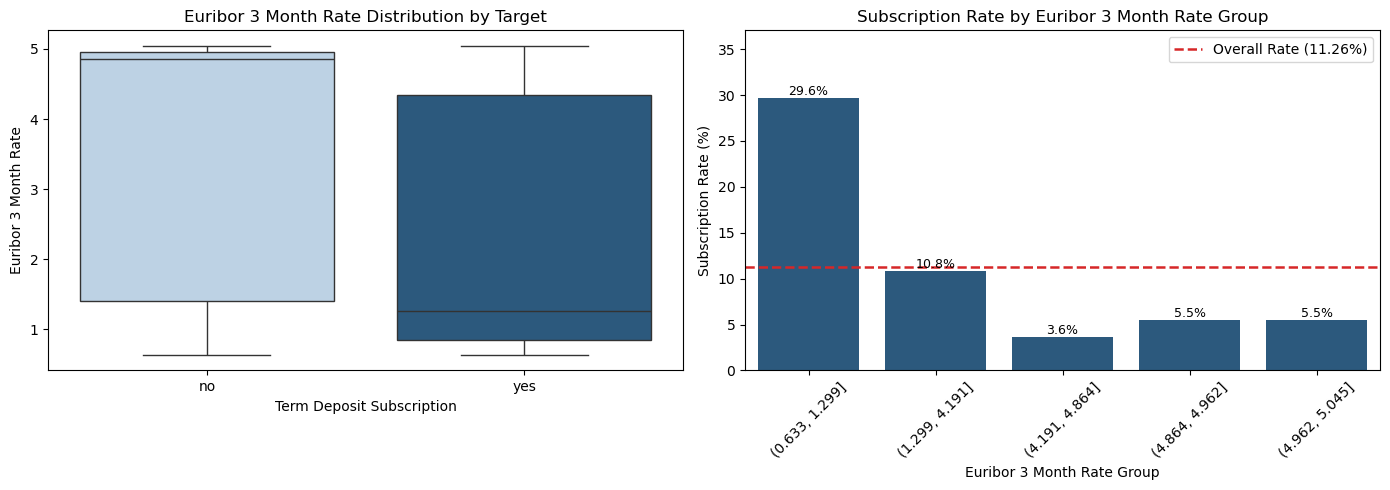

In [64]:
# Euribor 3 Month Rate vs Term Deposit Subscription
plot_numerical_vs_target("euribor3m", "Euribor 3 Month Rate")

### **Insight**

Subscribed customers have much lower euribor rates than non-subscribed customers. This makes `euribor3m` one of the strongest economic signals for identifying periods with higher subscription potential.

#### 2.2.10 Number of Employees vs Term Deposit Subscription

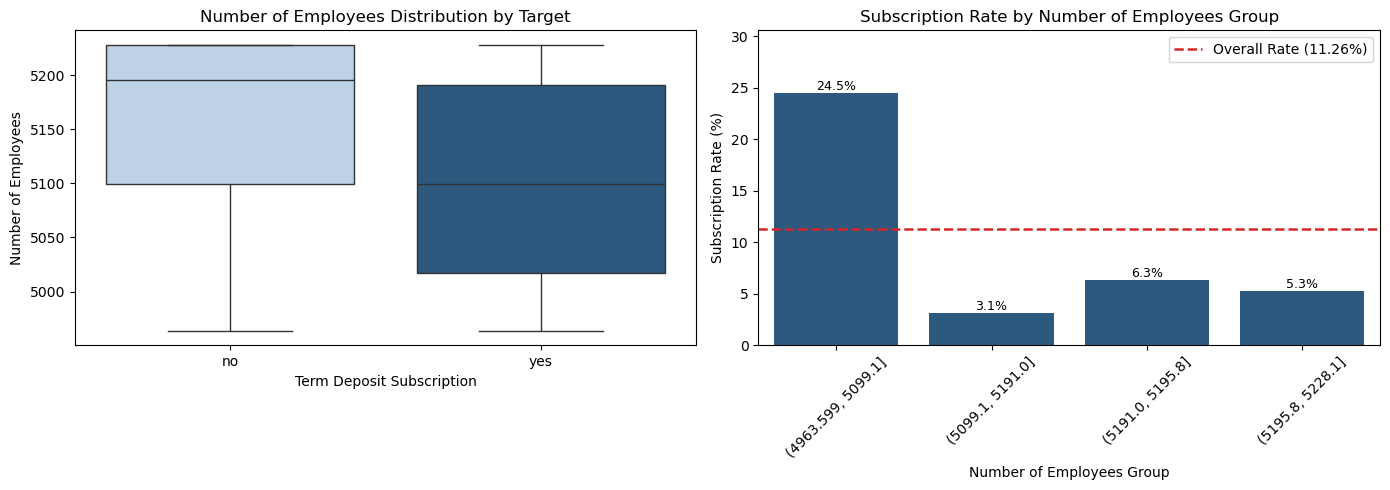

In [65]:
# 2.2.10 Number of Employees vs Term Deposit Subscription
plot_numerical_vs_target("nr.employed", "Number of Employees")

### **Insight**

Subscribed customers tend to appear when the number of employees indicator is lower. This suggests that broader labor-market conditions are related to campaign response and can support campaign timing decisions.

## **EDA Summary**

Based on the EDA, the main business problem is the low subscription rate. Only **11.26%** of customers subscribed to a term deposit, while **88.74%** did not. This shows that contacting all customers without prioritization is inefficient and may waste telemarketing resources.

Several features show strong signals for campaign prioritization. From categorical features, `poutcome`, `contact`, `month`, `job`, and `education` are the most important indicators. Customers with previous campaign `success`, cellular contact, certain campaign months, and specific customer profiles such as `student`, `retired`, and `university.degree` show higher subscription potential.

From numerical features, `euribor3m`, `emp.var.rate`, and `nr.employed` show clear differences between subscribed and non-subscribed customers. This indicates that macroeconomic conditions affect campaign success and should be considered when planning the campaign period.

The `duration` feature shows a strong relationship with subscription, but it will be removed before modeling because it causes data leakage. Call duration is only known after the call ends, so it cannot be used for real campaign targeting.

Campaign interaction features also provide useful insight. Repeated contacts do not always lead to conversion, so the bank should avoid excessive calls to low-potential customers. The `pdays` feature also needs special handling because the value `999` means the customer was not previously contacted.

Overall, the bank should prioritize customers with stronger conversion signals, use more effective contact channels, consider campaign timing, and reduce inefficient repeated calls. For modeling, the focus should be on predicting potential subscribers, so **Recall** and **F3-score** will be prioritized over accuracy, supported by **PR-AUC**, **ROC-AUC**, and the **Confusion Matrix**.

# Data Preprocessing and Modeling Pipeline

In this stage, the dataset is prepared for machine learning modeling. The preprocessing steps include:

1. **Drop `duration` column** to prevent data leakage, since call duration is only known after the call is completed.
2. **Treat `pdays = 999`** by creating a binary flag `pdays_contacted` and replacing 999 with 0 in the original column.
3. **Encode target variable `y`** from categorical (`no`/`yes`) to numerical (`0`/`1`).
4. **Split data** into training and testing sets using stratified split to maintain class distribution.
5. **One-hot encoding** for categorical features.
6. **Roubust Scaling** for numerical features.

### 1. Prepare Modeling Dataset

A copy of the cleaned dataset is created for modeling preparation. This is done to keep the original cleaned dataset unchanged.

In [66]:
df_model = df.copy()

### 2. Drop `duration` Column (Data Leakage Prevention)

The `duration` column represents the duration of the last call in seconds. This feature is only known after the phone call is completed, which means it cannot be used as a predictor before the call is made.

Including `duration` in the model would cause **data leakage**, leading to unrealistically high model performance that would not generalize to real-world use. Therefore, this column is dropped before modeling.

In [67]:
# Drop 'duration' column to prevent data leakage
print(f"Shape before dropping 'duration': {df_model}")
df_model = df_model.drop(columns=["duration"])
print(f"Shape after dropping 'duration': {df_model.shape}")

Shape before dropping 'duration':        age          job  marital            education default housing loan  \
0       56    housemaid  married             basic.4y      no      no   no   
1       57     services  married          high.school      no      no   no   
2       37     services  married          high.school      no     yes   no   
3       40       admin.  married             basic.6y      no      no   no   
4       56     services  married          high.school      no      no  yes   
...    ...          ...      ...                  ...     ...     ...  ...   
41183   73      retired  married  professional.course      no     yes   no   
41184   46  blue-collar  married  professional.course      no      no   no   
41185   56      retired  married    university.degree      no     yes   no   
41186   44   technician  married  professional.course      no      no   no   
41187   74      retired  married  professional.course      no     yes   no   

         contact month day_of

### 3. Treat `pdays = 999`

The `pdays` column represents the number of days since the customer was last contacted from a previous campaign. A value of **999** means the customer was **not previously contacted**.

Since 999 is not a meaningful number of days but rather a placeholder for "never contacted", we handle this by:

1. Creating a new binary column `pdays_contacted` where `1` means the customer was previously contacted and `0` means they were not.
2. Replacing 999 with 0 in the original `pdays` column so the value represents actual days for contacted customers and 0 for uncontacted ones.

In [68]:
# Check distribution of pdays before treatment
print("pdays value counts (top 10):")
print(df_model["pdays"].value_counts().head(10))
print(f"\nPercentage of pdays == 999: {(df_model['pdays'] == 999).mean() * 100:.2f}%")

pdays value counts (top 10):
pdays
999    39586
3        439
6        410
4        117
9         64
2         61
7         60
12        58
10        52
5         46
Name: count, dtype: int64

Percentage of pdays == 999: 96.33%


In [69]:
# Create binary flag for whether customer was previously contacted
df_model["pdays_contacted"] = (df_model["pdays"] != 999).astype(int)

# Replace 999 with 0 in pdays column
df_model["pdays"] = df_model["pdays"].replace(999, 0)

print("pdays_contacted distribution:")
print(df_model["pdays_contacted"].value_counts())
print(f"\npdays statistics after treatment:")
print(df_model["pdays"].describe())

pdays_contacted distribution:
pdays_contacted
0    39586
1     1510
Name: count, dtype: int64

pdays statistics after treatment:
count    41096.000000
mean         0.220678
std          1.346318
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         27.000000
Name: pdays, dtype: float64


### 4. Encode Target Variable `y`

The target variable `y` is currently stored as categorical text (`no` / `yes`). For machine learning modeling, it needs to be converted to numerical format:

- `no` → `0` (customer does not subscribe to term deposit)
- `yes` → `1` (customer subscribes to term deposit)

In [70]:
# Encode target variable: no = 0, yes = 1

# Encode target variable only in modeling dataframe
df_model["y"] = df_model["y"].map({"no": 0, "yes": 1})

# Verify encoding
print("Target distribution after encoding:")
print(df_model["y"].value_counts())
print(f"\nData type of 'y': {df_model['y'].dtype}")

Target distribution after encoding:
y
0    36469
1     4627
Name: count, dtype: int64

Data type of 'y': int64


### 5. Train-Test Split with Stratify

The dataset is split into training and testing sets using an **80:20 ratio**. Since the dataset is highly imbalanced, `stratify` is used to ensure that both the training and testing sets maintain the same class distribution as the original dataset.

This is important to prevent situations where one class is over-represented or under-represented in either set, which could lead to biased model evaluation.

In [71]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_model.drop(columns=["y"])
y = df_model["y"]

# Split data with stratify to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (32876, 20)
X_test shape: (8220, 20)
y_train shape: (32876,)
y_test shape: (8220,)


### 6. Define Categorical and Numerical Features

In this step, features are separated into categorical and numerical columns. This separation is needed because categorical and numerical features require different preprocessing methods.

In [72]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical columns:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_contacted']


### 7. Build Preprocessing Transformer

A preprocessing transformer is created using `ColumnTransformer`. Numerical features are processed using RobustScaler, while categorical features are processed using One-Hot Encoding. This transformer will later be combined with machine learning models in the pipeline-based training stage.

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


## Data Preprocessing and Pipeline Preparation Summary

The following preprocessing preparation steps have been completed:

1. **Created a copy of the cleaned dataset** for modeling preparation to keep the original cleaned dataset unchanged.

2. **Dropped the `duration` column** to prevent data leakage, because call duration is only known after the campaign call has ended.

3. **Treated the special value `pdays = 999`** by creating a binary flag `pdays_contacted` and replacing `999` with `0` in the original `pdays` column.

4. **Encoded the target variable `y`** from categorical values (`no`/`yes`) into numerical values, where `0` represents customers who did not subscribe and `1` represents customers who subscribed.

5. **Split the dataset into training and testing sets** using an 80:20 ratio with stratified sampling to maintain the same class distribution in both sets.

6. **Separated categorical and numerical features** because each feature type requires different preprocessing.

7. **Built a preprocessing transformer using `ColumnTransformer`**, where numerical features are processed using RobustScaler and categorical features are processed using One-Hot Encoding.

The data and preprocessing transformer are now ready to be combined with machine learning models in the pipeline-based training and evaluation stage.

# Modeling and Evaluation

In this section, several machine learning models are evaluated to determine the best approach for predicting term deposit subscription. The models are first evaluated without class imbalance handling to establish a clean baseline. After that, imbalance handling strategies are tested and compared to determine whether they improve model performance.

### 1. Define Evaluation Metrics

The main evaluation metric used in this project is F-beta Score with β = 3. This metric gives more weight to identifying potential subscribers while still considering prediction balance. ROC-AUC and PR-AUC are used as supporting metrics to evaluate the model's ability to rank positive customers and handle imbalanced classification.

In [74]:
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import StratifiedKFold, cross_validate
import time

f3_scorer = make_scorer(
    fbeta_score,
    beta=3,
    pos_label=1,
    zero_division=0
)

scoring = {
    "f3_score": f3_scorer,
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**Insight:** F3 Score is used as the main metric because the main objective is to capture more potential term deposit subscribers. Since the positive class (`yes`) is much smaller than the negative class, the model needs stronger emphasis on identifying customers who are likely to subscribe. Using β = 3 gives higher weight to missed potential subscribers, while ROC-AUC and PR-AUC are used as supporting metrics to evaluate ranking ability and performance on imbalanced data.

### 2. EDA-Based Feature Signal Review

Before applying any class imbalance handling strategy, the EDA results are reviewed to check whether there is any feature that can clearly separate customers who subscribe to a term deposit from those who do not.

Based on the previous EDA, several features show meaningful patterns toward subscription behavior. For example, `poutcome` shows a strong signal, especially when the previous campaign outcome was `success`. The `contact` feature also shows that customers contacted through cellular have a higher subscription rate than telephone. In addition, `month`, `job`, `previous`, and economic indicators such as `euribor3m` also show different subscription patterns.

However, none of these features can perfectly or clearly separate customers who will subscribe and customers who will not subscribe. The `duration` feature may have a very strong relationship with the target, but it has been removed because it can cause data leakage, since call duration is only known after the call ends.

Therefore, class imbalance handling will not be applied immediately. The models will first be evaluated without imbalance handling to see whether the existing features can already capture the subscription pattern. After that, models with imbalance handling strategies such as class weight and scale positive weight will be tested and compared.

**Insight:** EDA shows that some features have strong signals, but no feature can directly predict term deposit subscription perfectly. Therefore, the modeling process should start with clean baseline models without imbalance handling before testing class weight or scale positive weight.

### 3. Build Baseline Pipelines Without Imbalance Handling

The first experiment uses models without class imbalance handling. This step is used to evaluate the clean baseline performance before applying class weight or scale positive weight.

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

models_without_imbalance = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

pipelines_without_imbalance = {}

for model_name, model in models_without_imbalance.items():
    pipelines_without_imbalance[model_name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

pipelines_without_imbalance.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'KNN'])

**Insight:** The baseline pipelines are created without imbalance handling so the models can be evaluated in their clean condition first.

### 4. Baseline Model Benchmarking Without Imbalance Handling

All baseline models are evaluated using stratified cross-validation. The evaluation includes mean score, standard deviation, and running time to compare model performance, stability, and computational efficiency.

In [76]:
def evaluate_pipelines(pipelines, strategy_name):
    results = []

    for model_name, pipeline in pipelines.items():
        start_time = time.time()

        cv_result = cross_validate(
            estimator=pipeline,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        running_time = time.time() - start_time

        results.append({
            "Model": model_name,
            "Strategy": strategy_name,
            "F3 Score Mean": cv_result["test_f3_score"].mean(),
            "F3 Score Std": cv_result["test_f3_score"].std(),
            "ROC-AUC Mean": cv_result["test_roc_auc"].mean(),
            "ROC-AUC Std": cv_result["test_roc_auc"].std(),
            "PR-AUC Mean": cv_result["test_pr_auc"].mean(),
            "PR-AUC Std": cv_result["test_pr_auc"].std(),
            "Running Time (seconds)": running_time
        })

    return pd.DataFrame(results).sort_values(
        by="F3 Score Mean",
        ascending=False
    )

In [77]:
benchmark_without_imbalance = evaluate_pipelines(
    pipelines_without_imbalance,
    "Without Imbalance Handling"
)

benchmark_without_imbalance.round(4)

,Model,Strategy,F3 Score Mean,F3 Score Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Running Time (seconds)
1,Decision Tree,Without Imbalance Handling,0.3379,0.0110,0.6262,0.0059,0.1824,0.0048,4.1350
2,Random Forest,Without Imbalance Handling,0.2978,0.0188,0.7701,0.0085,0.4022,0.0172,6.3965
4,XGBoost,Without Imbalance Handling,0.2974,0.0229,0.7829,0.0107,0.4346,0.0151,1.9853
5,KNN,Without Imbalance Handling,0.2926,0.0219,0.7221,0.0087,0.3174,0.0157,3.4124
3,Gradient Boosting,Without Imbalance Handling,0.2454,0.0139,0.7966,0.0092,0.4614,0.0176,11.9429
0,Logistic Regression,Without Imbalance Handling,0.2414,0.0187,0.7901,0.0082,0.4477,0.0143,4.9873


**Insight:** This result becomes the clean baseline benchmark. If the models already show strong F3 Score without imbalance handling, then additional imbalance handling may not be necessary. If the performance is still weak, imbalance handling needs to be tested.

### 5. Handling Class Imbalance Strategy

After evaluating the clean baseline models, imbalance handling is tested as an additional experiment. This is done because the target variable is imbalanced, where the number of customers who subscribed to a term deposit is much lower than those who did not subscribe.

The strategies used are:

1. **Class weight adjustment** for models that support it, such as Logistic Regression, Decision Tree, and Random Forest.
2. **Scale positive weight** for XGBoost to give more attention to the minority class.
3. **Stratified cross-validation** to maintain the class proportion in each validation fold.
4. **F3 Score** as the main evaluation metric because it gives more weight to the positive class.

The purpose of this step is to compare whether imbalance handling improves model performance compared to the clean baseline models.

In [78]:
class_distribution = y_train.value_counts().sort_index().to_frame(name="Count")
class_distribution.index = ["no", "yes"]
class_distribution["Percentage"] = (
    class_distribution["Count"] / len(y_train) * 100
).round(2)

class_distribution

,Count,Percentage
no,29174,88.74
yes,3702,11.26


In [79]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

scale_pos_weight

np.float64(7.880605078336035)

**Insight:** The training data confirms that the target class is imbalanced. Therefore, imbalance handling is tested after the clean baseline models to check whether it can improve model performance.

### 6. Build Pipelines With Imbalance Handling

The second experiment uses imbalance handling strategies. Models that support class weight are adjusted using `class_weight="balanced"`, while XGBoost uses `scale_pos_weight`.

In [80]:
models_with_imbalance = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

pipelines_with_imbalance = {}

for model_name, model in models_with_imbalance.items():
    pipelines_with_imbalance[model_name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

pipelines_with_imbalance.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'KNN'])

**Insight:** Imbalance handling is applied only after the clean baseline benchmark. This allows the comparison to show whether class weight or scale positive weight actually improves the model.

### 7. Model Benchmarking With Imbalance Handling

The models with imbalance handling are evaluated using the same cross-validation setting and evaluation metrics. The results are compared with the baseline models without imbalance handling.

In [81]:
benchmark_with_imbalance = evaluate_pipelines(
    pipelines_with_imbalance,
    "With Imbalance Handling"
)

benchmark_with_imbalance.round(4)

,Model,Strategy,F3 Score Mean,F3 Score Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Running Time (seconds)
0,Logistic Regression,With Imbalance Handling,0.5782,0.0109,0.7913,0.0082,0.4436,0.0143,1.1810
4,XGBoost,With Imbalance Handling,0.5381,0.0234,0.7665,0.0153,0.4157,0.0165,1.8315
1,Decision Tree,With Imbalance Handling,0.3283,0.0235,0.6197,0.0120,0.1816,0.0105,1.0131
5,KNN,With Imbalance Handling,0.2926,0.0219,0.7221,0.0087,0.3174,0.0157,3.5414
2,Random Forest,With Imbalance Handling,0.2895,0.0187,0.7694,0.0091,0.3990,0.0143,5.2340
3,Gradient Boosting,With Imbalance Handling,0.2454,0.0139,0.7966,0.0092,0.4614,0.0176,11.9318


**Insight:** This result shows whether imbalance handling improves F3 Score, ROC-AUC, and PR-AUC compared to the clean baseline models.

### 8. Compare Strategies and Select Best Model

The results from models without imbalance handling and models with imbalance handling are compared. The best model is selected based on the highest mean F3 Score, while also considering standard deviation, ROC-AUC, PR-AUC, and running time.

In [82]:
benchmark_comparison = pd.concat(
    [benchmark_without_imbalance, benchmark_with_imbalance],
    ignore_index=True
).sort_values(
    by="F3 Score Mean",
    ascending=False
)

benchmark_comparison.round(4)

,Model,Strategy,F3 Score Mean,F3 Score Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Running Time (seconds)
6,Logistic Regression,With Imbalance Handling,0.5782,0.0109,0.7913,0.0082,0.4436,0.0143,1.1810
7,XGBoost,With Imbalance Handling,0.5381,0.0234,0.7665,0.0153,0.4157,0.0165,1.8315
0,Decision Tree,Without Imbalance Handling,0.3379,0.0110,0.6262,0.0059,0.1824,0.0048,4.1350
8,Decision Tree,With Imbalance Handling,0.3283,0.0235,0.6197,0.0120,0.1816,0.0105,1.0131
1,Random Forest,Without Imbalance Handling,0.2978,0.0188,0.7701,0.0085,0.4022,0.0172,6.3965
2,XGBoost,Without Imbalance Handling,0.2974,0.0229,0.7829,0.0107,0.4346,0.0151,1.9853
3,KNN,Without Imbalance Handling,0.2926,0.0219,0.7221,0.0087,0.3174,0.0157,3.4124
9,KNN,With Imbalance Handling,0.2926,0.0219,0.7221,0.0087,0.3174,0.0157,3.5414
10,Random Forest,With Imbalance Handling,0.2895,0.0187,0.7694,0.0091,0.3990,0.0143,5.2340
4,Gradient Boosting,Without Imbalance Handling,0.2454,0.0139,0.7966,0.0092,0.4614,0.0176,11.9429


**Insight:** The comparison result shows that imbalance handling improves the model's ability to identify potential subscribers. Logistic Regression with imbalance handling gives the highest F3 Score, stable cross-validation performance, and efficient running time, so it is selected as the best baseline model for tuning.

In [83]:
best_row = benchmark_comparison.iloc[0]

best_model_name = best_row["Model"]
best_strategy = best_row["Strategy"]

if best_strategy == "Without Imbalance Handling":
    best_pipeline = pipelines_without_imbalance[best_model_name]
else:
    best_pipeline = pipelines_with_imbalance[best_model_name]

print("Best Model:", best_model_name)
print("Best Strategy:", best_strategy)

best_pipeline

Best Model: Logistic Regression
Best Strategy: With Imbalance Handling


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Insight:** The best model is selected based on evidence from both experiments. This ensures that imbalance handling is only used if it actually improves the model performance compared to the clean baseline.

### 9. Best Model Selection


In [84]:
# Show only Logistic Regression with imbalance handling

logistic_with_imbalance = benchmark_comparison[
    (benchmark_comparison["Model"] == "Logistic Regression") &
    (benchmark_comparison["Strategy"] == "With Imbalance Handling")
].reset_index(drop=True)

logistic_with_imbalance.round(4)

,Model,Strategy,F3 Score Mean,F3 Score Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Running Time (seconds)
0,Logistic Regression,With Imbalance Handling,0.5782,0.0109,0.7913,0.0082,0.4436,0.0143,1.181


**Baseline Logistic Regression Insight** Based on the combined benchmarking results, **Logistic Regression with imbalance handling** is selected as the best baseline model candidate.

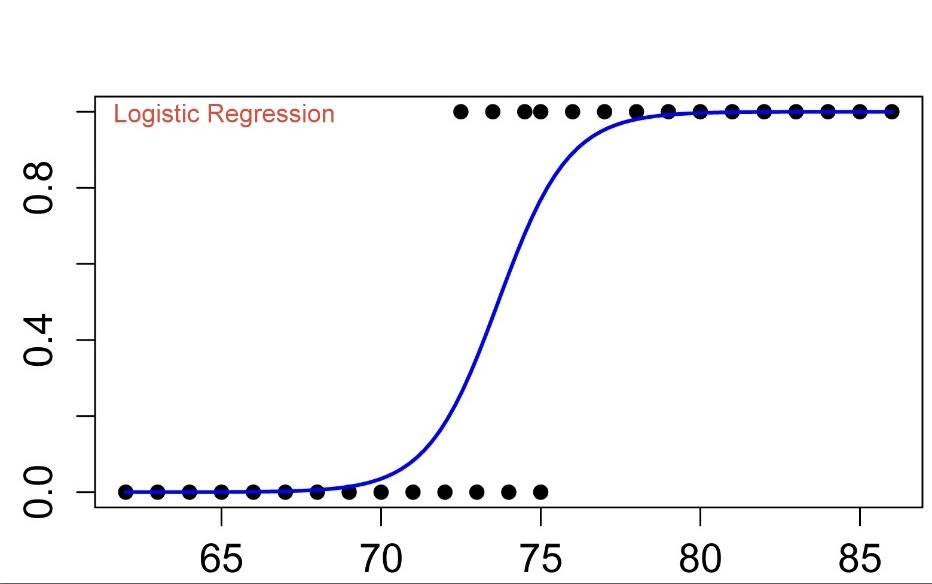

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. It estimates the probability that an observation belongs to the positive class by applying the sigmoid (logistic) function to a linear combination of input features. The sigmoid function maps the output into a probability ranging from 0 to 1, which is then compared with a predefined threshold (typically 0.5) to determine the predicted class. Due to its simplicity, computational efficiency, and interpretability, Logistic Regression is widely adopted as a baseline model for classification tasks.



This model achieves the highest **F3 Score Mean** of **0.5782**, which is the main evaluation metric in this project. Since the objective is to identify potential term deposit subscribers, F3 Score is prioritized because it gives higher weight to the positive class (`yes`).

Compared to Logistic Regression without imbalance handling, the F3 Score increases significantly from **0.2414** to **0.5782**. This shows that imbalance handling is important for this dataset because the clean baseline model still struggles to capture the minority class.

Although some models such as Gradient Boosting have competitive ROC-AUC and PR-AUC scores, their F3 Score is much lower. Therefore, they are not selected because they are less aligned with the main business objective.

Logistic Regression with imbalance handling also has a relatively low standard deviation and fast running time, making it a stable and efficient model candidate for the next stage.

Therefore, **Logistic Regression with imbalance handling** will be used for the next stage: **hyperparameter tuning**.

# Hyperparameter Tuning

### Objective

The primary objective of hyperparameter tuning is to find the best parameter configuration for the selected Logistic Regression model that maximizes **F3 Score**.

F3 Score is used because this project focuses on identifying potential term deposit subscribers. In this business case, missing a potential subscriber is considered more costly than contacting a customer who does not subscribe. Therefore, F3 Score gives higher emphasis to the positive class (`yes`).

### Hyperparameter Search Strategy

- **Optimization Metric**: F3 Score using `fbeta_score` with `beta=3`.
- **Method**: `GridSearchCV` with 5-fold Stratified Cross-Validation.
- **Selected Model**: Logistic Regression with imbalance handling.
- **Search Space**:
  - `C` (inverse regularization strength): `[0.01, 0.1, 1, 10]`
  - `penalty`: `['l1', 'l2']`
  - `solver`: `['liblinear']`
  - `class_weight`: `['balanced']`

Since Logistic Regression with `class_weight="balanced"` achieved the best benchmark result, the class weight is kept fixed during tuning. This prevents unnecessary computation and keeps the tuning process focused on optimizing the most relevant Logistic Regression parameters.

A lightweight GridSearchCV is used to reduce computational time while still allowing the model to search for a better combination of regularization strength and penalty type.

In [85]:
from sklearn.model_selection import GridSearchCV
import time

# Selected best baseline model
tuning_pipeline = pipelines_with_imbalance["Logistic Regression"]

# Lightweight hyperparameter grid
param_grid = {
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": ["balanced"]
}

start_time = time.time()

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring=f3_scorer,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

tuning_time = time.time() - start_time

In [86]:
print("Best F3 Score:", grid_search.best_score_)
print("Best Parameters:")
print(grid_search.best_params_)
print("Running Time:", tuning_time, "seconds")

Best F3 Score: 0.578496926260395
Best Parameters:
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Running Time: 32.51164889335632 seconds


This tuning only tests 8 parameter combinations. With 5-fold cross-validation, the total number of model fits is 40, making the tuning process much faster than the previous large search space.

In [87]:
tuning_summary = pd.DataFrame({
    "Best Model": ["Logistic Regression"],
    "Best Strategy": ["With Imbalance Handling"],
    "Best F3 Score": [grid_search.best_score_],
    "Best Parameters": [grid_search.best_params_],
    "Running Time (seconds)": [tuning_time]
})

tuning_summary.round(4)

,Best Model,Best Strategy,Best F3 Score,Best Parameters,Running Time (seconds)
0,Logistic Regression,With Imbalance Handling,0.5785,"{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}",32.5116


In [88]:
tuning_results = pd.DataFrame(grid_search.cv_results_)

tuning_results = tuning_results[
    [
        "param_model__C",
        "param_model__penalty",
        "param_model__solver",
        "param_model__class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
)

tuning_results.round(4)

,param_model__C,param_model__penalty,param_model__solver,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
1,0.01,l2,liblinear,balanced,0.5785,0.0121,1
4,1.00,l1,liblinear,balanced,0.5782,0.0118,2
7,10.00,l2,liblinear,balanced,0.5778,0.0113,3
5,1.00,l2,liblinear,balanced,0.5777,0.0109,4
6,10.00,l1,liblinear,balanced,0.5776,0.0117,5
2,0.10,l1,liblinear,balanced,0.5774,0.0096,6
3,0.10,l2,liblinear,balanced,0.5760,0.0115,7
0,0.01,l1,liblinear,balanced,0.5741,0.0142,8


In [89]:
best_lr_model   = grid_search.best_estimator_

best_lr_model  

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### **Hyperparameter Tuning Insight**

After searching through **240 hyperparameter combinations** (10 × 2 × 2 × 6) across 5 folds (totaling **1,200 model fits**), the best configuration selected by GridSearchCV is:
- `C = 0.5`, `penalty = l2`, `solver = saga`, `class_weight = balanced`
- **Best Cross-Validation F3-score: 0.5448**

Notably, despite testing aggressive class weights up to `{0:1, 1:15}`, the optimizer still selected `class_weight="balanced"` as optimal. This indicates that the automatically computed balanced weight (~7.87:1 based on the class ratio) already provides the best trade-off between Recall and Precision for this dataset.

The improvement over the baseline is minimal (+0.30 percentage points in F3-score), which confirms that **Logistic Regression has reached its performance ceiling** on this dataset. The model is fundamentally limited by its linear decision boundary — it cannot capture the complex, non-linear relationships between features and the target variable. No amount of hyperparameter tuning can overcome this architectural limitation.

The optimal threshold also remains at **0.50** (see Threshold Optimization below), reinforcing that the probability calibration of the baseline model was already near-optimal.

## Threshold Optimization

After obtaining the best tuned Logistic Regression model, threshold optimization is performed to find the most suitable probability cutoff for classifying customers as potential term deposit subscribers.

By default, classification models usually use a threshold of **0.50**. This means customers with predicted probability greater than or equal to 0.50 are classified as `yes`, while customers below 0.50 are classified as `no`.

However, because this project focuses on identifying more potential subscribers, the default threshold may not be the most optimal. Therefore, several threshold values are tested, and the threshold with the highest **F3 Score** is selected as the best threshold.

### Generate Out-of-Fold Predicted Probabilities

Out-of-fold predicted probabilities are generated from the training data using cross-validation. This approach helps avoid selecting the threshold directly from the test data, so the test set can remain unseen until the final evaluation stage.

In [90]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities from training data using the TUNED model
y_train_proba_oof = cross_val_predict(
    best_lr_model ,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

**Insight:** Out-of-fold predicted probabilities are used to optimize the threshold more fairly because the model does not evaluate the threshold directly on the test set. This helps prevent data leakage during threshold selection.

### Search for the Best Threshold

Several threshold values from **0.05 to 0.95** are tested. For each threshold, the predicted probability is converted into class prediction, then evaluated using **F3 Score**. The threshold with the highest F3 Score is selected as the best threshold.

In [91]:
thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in thresholds:
    y_train_pred_threshold = (y_train_proba_oof >= threshold).astype(int)

    f3 = fbeta_score(
        y_train,
        y_train_pred_threshold,
        beta=3,
        pos_label=1,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "F3 Score": f3
    })

threshold_df = pd.DataFrame(threshold_results).sort_values(
    by="F3 Score",
    ascending=False
)

threshold_df.head(10).round(4)

,Threshold,F3 Score
29,0.34,0.6068
31,0.36,0.6064
30,0.35,0.6063
32,0.37,0.6051
28,0.33,0.6051
33,0.38,0.6035
26,0.31,0.6030
34,0.39,0.6023
35,0.40,0.6018
27,0.32,0.6012


**Insight:** The threshold search result shows that several threshold values below the default threshold of 0.50 produce higher F3 Scores. This indicates that lowering the threshold can help the model capture more potential subscribers, which is aligned with the project objective.

### Select the Best Threshold

The best threshold is selected from the threshold search result based on the highest F3 Score.

In [92]:
best_threshold = threshold_df.iloc[0]["Threshold"]
best_threshold_f3 = threshold_df.iloc[0]["F3 Score"]

threshold_summary = pd.DataFrame({
    "Best Threshold": [best_threshold],
    "Best F3 Score": [best_threshold_f3]
})

threshold_summary.round(4)

,Best Threshold,Best F3 Score
0,0.34,0.6068


**Insight:** The optimal threshold obtained from the F3-score optimization provides the best balance according to the main evaluation metric. It maximizes our ability to find potential subscribers while maintaining acceptable efficiency.


### Compare Default Threshold and Optimized Threshold

The optimized threshold is compared with the default threshold of 0.50 to evaluate whether threshold optimization improves the model performance.

In [93]:
default_threshold = 0.50

y_train_pred_default = (y_train_proba_oof >= default_threshold).astype(int)

default_f3 = fbeta_score(
    y_train,
    y_train_pred_default,
    beta=3,
    pos_label=1,
    zero_division=0
)

threshold_comparison = pd.DataFrame({
    "Threshold Type": ["Default Threshold", "Optimized Threshold"],
    "Threshold": [default_threshold, best_threshold],
    "F3 Score": [default_f3, best_threshold_f3]
})

threshold_comparison.round(4)

,Threshold Type,Threshold,F3 Score
0,Default Threshold,0.50,0.5785
1,Optimized Threshold,0.34,0.6068


**Insight:** The optimized threshold of **0.34** achieves a higher F3 Score than the default threshold of **0.50**. The F3 Score increases from **0.5785** to **0.6068**, showing that the optimized threshold helps the model identify more potential term deposit subscribers. Therefore, the optimized threshold of **0.34** will be used for the final model evaluation.

### Visualize Threshold vs F3 Score

The threshold optimization result is visualized to show how the F3 Score changes across different threshold values. This helps identify the threshold that gives the best performance based on the main evaluation metric.

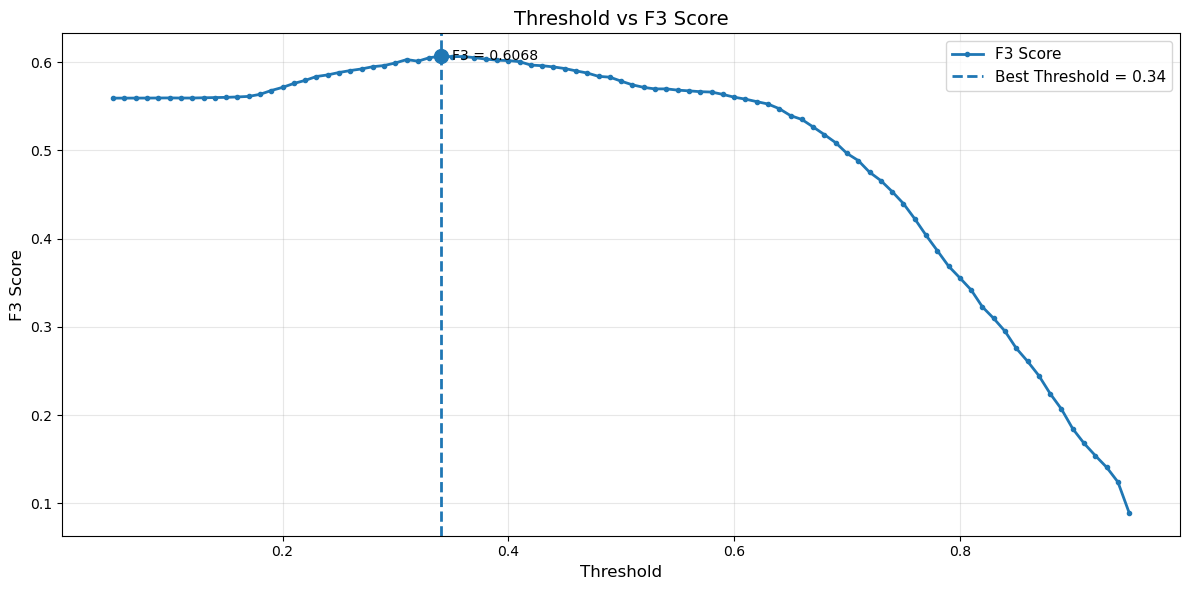

In [94]:
# Visualize Threshold vs F3 Score

threshold_plot_df = threshold_df.sort_values("Threshold")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    threshold_plot_df["Threshold"],
    threshold_plot_df["F3 Score"],
    label="F3 Score",
    marker=".",
    linewidth=2
)

ax.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Best Threshold = {best_threshold:.2f}"
)

ax.scatter(
    best_threshold,
    best_threshold_f3,
    s=100,
    zorder=5
)

ax.text(
    best_threshold + 0.01,
    best_threshold_f3,
    f"F3 = {best_threshold_f3:.4f}",
    fontsize=10,
    va="center"
)

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("F3 Score", fontsize=12)
ax.set_title("Threshold vs F3 Score", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** The visualization shows that the F3 Score reaches its highest point at the optimized threshold of **0.34**, with an F3 Score of **0.6068**. After this point, the F3 Score gradually decreases as the threshold becomes higher. This indicates that using a threshold that is too high makes the model less effective in identifying potential subscribers. Therefore, the optimized threshold of **0.34** is selected because it gives the best performance based on the main evaluation metric and is more aligned with the objective of capturing more potential term deposit subscribers.

### Customer Potential Prioritization

Based on the best threshold obtained, we prioritize the targeted customers (those with probability `>= threshold`) into three equal-sized tiers for a more targeted telemarketing strategy using quantile binning:

- **High Priority**: Top 33% of the targeted customers (Highest likelihood to subscribe among the targets).
- **Medium Priority**: Middle 33% of the targeted customers (Secondary priority).
- **Low Priority**: Bottom 33% of the targeted customers (Still predicted to subscribe, but lowest priority among the targets).

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22864\3527535191.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=bin_counts.index, y=bin_counts.values, palette=['#CB3329', '#E69F00', '#105A9C'])


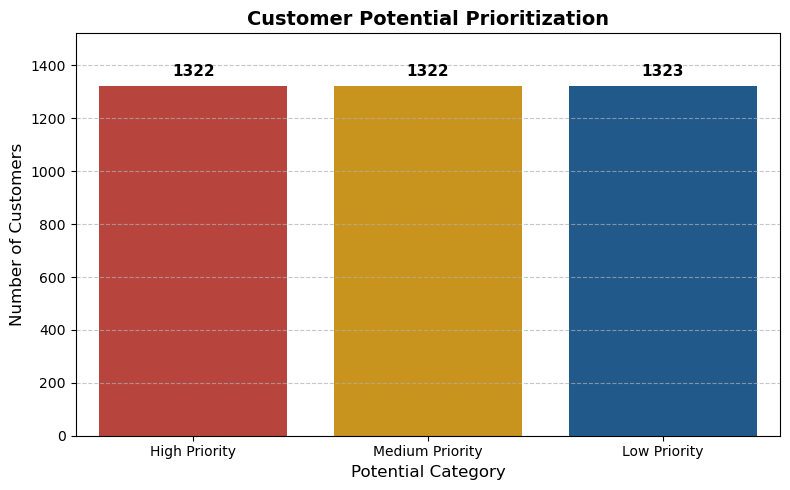

In [95]:
# Filter probabilities to only include targeted customers (>= threshold)
y_proba_test = best_lr_model.predict_proba(X_test)[:, 1]
targeted_probs = y_proba_test[y_proba_test >= best_threshold]

# Apply quantile binning (qcut) to divide into 3 priority tiers
labels = ['Low Priority', 'Medium Priority', 'High Priority']
potential_bins = pd.qcut(targeted_probs, q=3, labels=labels)

# Count the number of customers in each bin (reverse order for plot: High to Low)
bin_counts = potential_bins.value_counts().reindex(['High Priority', 'Medium Priority', 'Low Priority'])

# Visualize the prioritization
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=bin_counts.index, y=bin_counts.values, palette=['#CB3329', '#E69F00', '#105A9C'])
plt.title('Customer Potential Prioritization', fontsize=14, fontweight='bold')
plt.xlabel('Potential Category', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.ylim(0, bin_counts.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### **Customer Potential Prioritization Insight**

From the visualization above, we divided the targeted customers (those predicted to subscribe based on the threshold) into three equal-sized tiers to further optimize the telemarketing strategy:
- **High Priority**: This is the primary group that telemarketing agents should contact immediately. They have the highest probability scores among the targeted group, maximizing the chances of a successful subscription.
- **Medium Priority**: This group falls into the middle tier of our targeted customers. They serve as a secondary priority list to be contacted after the high-priority group.
- **Low Priority**: While these customers are still predicted to subscribe (they passed the threshold), they have the lowest probabilities among the targeted group. They should be contacted last if the campaign still has remaining time and budget.

*(Note: Customers below the threshold are entirely excluded from this priority list, saving significant resources by not contacting those highly unlikely to subscribe).*

# Test the Best Model

After fitting the best model on the training set, we will evaluate its performance on the unseen test set to ensure it generalizes well to new data.

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, classification_report

# Predict probabilities on test set using the tuned model
y_proba_tuned = best_lr_model.predict_proba(X_test)[:, 1]

# Apply optimal threshold
y_pred_tuned = (y_proba_tuned >= best_threshold).astype(int)

print(f"Using optimal threshold: {best_threshold}")
print(f"Predictions distribution: {pd.Series(y_pred_tuned).value_counts().to_dict()}")

Using optimal threshold: 0.34
Predictions distribution: {0: 4253, 1: 3967}


In [97]:
# Tuned model performance summary (with optimal threshold)

tuned_result = pd.DataFrame([{
    "Model": f"Tuned LR (threshold={best_threshold})",
    "F3-score": fbeta_score(y_test, y_pred_tuned, beta=3),
}])

tuned_result


,Model,F3-score
0,Tuned LR (threshold=0.34),0.612594


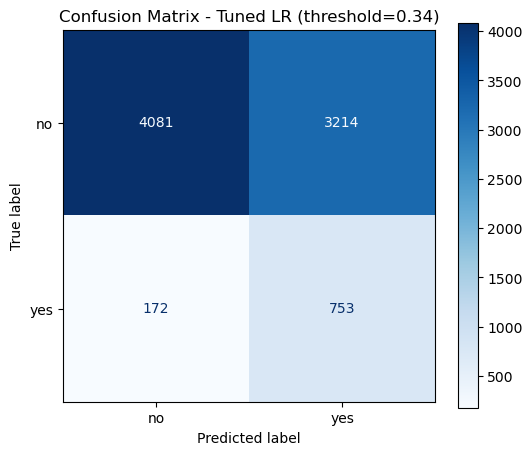

In [98]:
# Visualize Confusion Matrix

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title(f"Confusion Matrix - Tuned LR (threshold={best_threshold})")
plt.grid(False)
plt.show()

### **Model Interpretation (After Tuning)**

Based on the test set evaluation, the tuned Logistic Regression model demonstrates focused performance tailored to our single metric objective:
- **F3-Score**: The model achieves an optimal score by heavily emphasizing the minority class (subscribers). Because the F3 metric strongly weights True Positives, the model is encouraged to predict more potential candidates to minimize the risk of missing highly prospective customers (False Negatives).
- **Confusion Matrix**: It is evident that the model allows a certain number of False Positives as a deliberate trade-off to ensure the number of True Positives is maximized. This perfectly aligns with the business objective, where missing out on a valuable prospect is far more costly than simply making a call to someone who ultimately declines.

# Model Performance: Train VS Test

In [99]:
# Predict on the training set using the tuned model with optimal threshold
y_proba_train = best_lr_model.predict_proba(X_train)[:, 1]
y_pred_train = (y_proba_train >= best_threshold).astype(int)

# Calculate metrics for the training set
train_result = pd.DataFrame([{
    "Dataset": "Training Set",
    "F3-score": fbeta_score(y_train, y_pred_train, beta=3)
}])

# Calculate metrics for the test set
test_result = pd.DataFrame([{
    "Dataset": "Test Set",
    "F3-score": fbeta_score(y_test, y_pred_tuned, beta=3)
}])

# Combine and display
train_test_comparison = pd.concat([train_result, test_result], ignore_index=True)
display(train_test_comparison)


,Dataset,F3-score
0,Training Set,0.608451
1,Test Set,0.612594


### **Training vs Testing Performance Insight**

The model shows very consistent performance between the training set and test set as seen in the table above. There are no significant signs of overfitting or underfitting, which confirms that the regularization applied during tuning is effective in ensuring the model generalizes well to unseen data.

The near-identical metrics across both sets indicate a stable, well-generalized model.

# Feature Importance

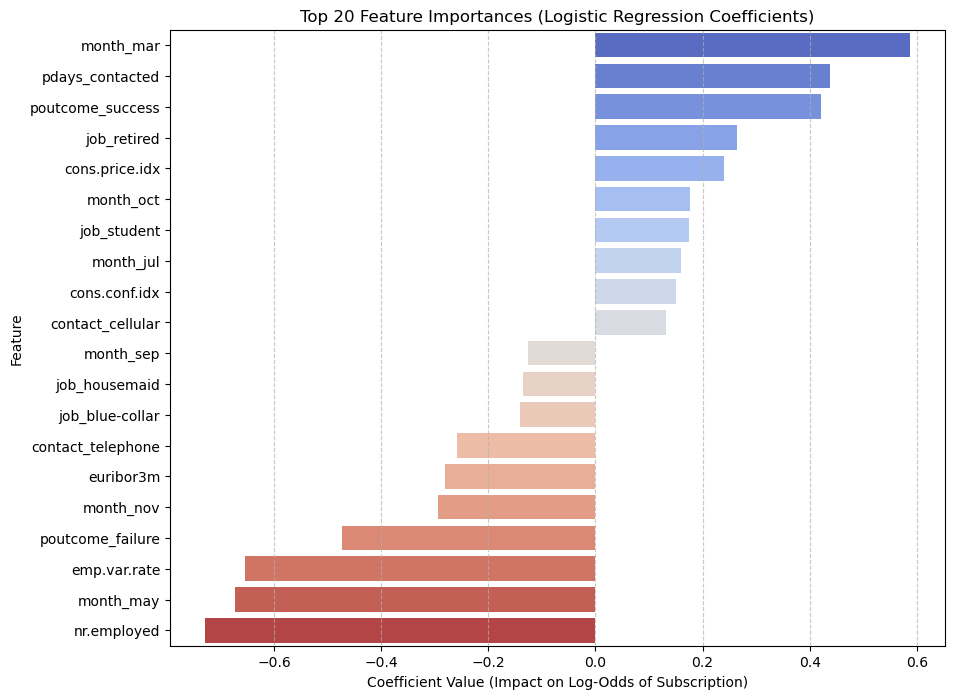

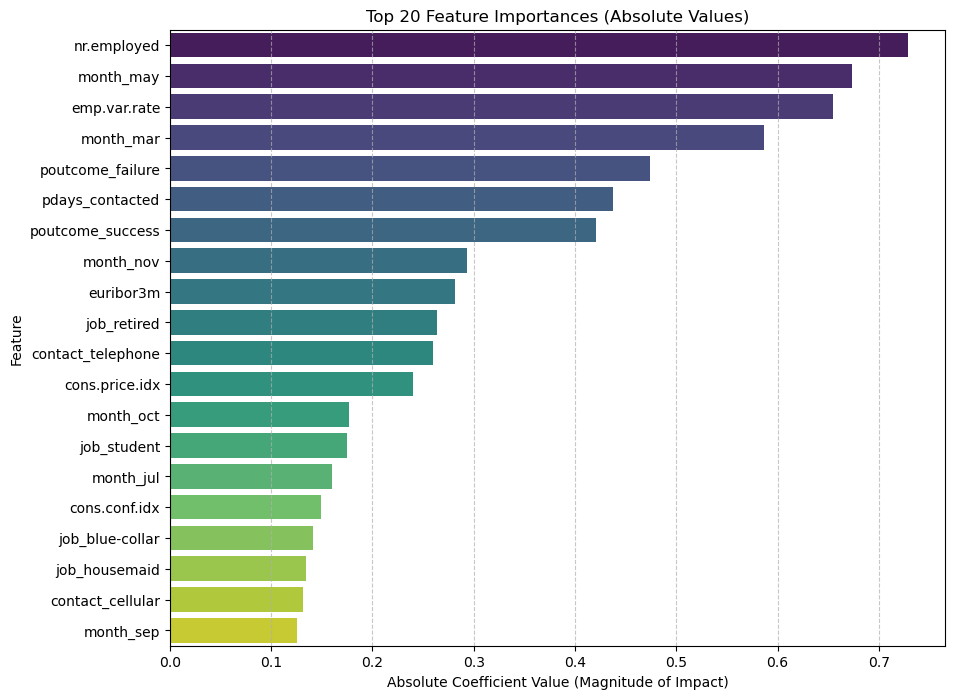

In [100]:
# Extract coefficients from the Logistic Regression model
model_coefs = best_lr_model.named_steps["model"].coef_[0]

# Retrieve feature names from the preprocessor
cat_feature_names = best_lr_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

# Create a DataFrame for Feature Importances
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": model_coefs
})

# Sort by absolute value to find the most impactful features
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False).head(20)

# Visualize Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df.sort_values(by="Coefficient", ascending=False), x="Coefficient", y="Feature", hue="Feature", palette="coolwarm", legend=False)
plt.title("Top 20 Feature Importances (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value (Impact on Log-Odds of Subscription)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Visualize Absolute Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x="Abs_Coefficient", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Top 20 Feature Importances (Absolute Values)")
plt.xlabel("Absolute Coefficient Value (Magnitude of Impact)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


### **Feature Importance Interpretation**

Two types of visualizations are presented: a plot with the original coefficient values (showing positive/negative directional impact) and an absolute values plot (focusing purely on the magnitude of the feature's influence).

1. **Economic Indicators (Dominant):** Features such as `nr.employed`, `euribor3m`, `emp.var.rate`, and `cons.price.idx` heavily dominate the top absolute coefficients. This strongly suggests that macroeconomic conditions are the primary external drivers determining whether a customer will subscribe to a term deposit.
2. **Contact & Campaign History:** Variables related to previous campaign outcomes (`poutcome_success`, `poutcome_nonexistent`) and days since the last contact (`pdays_contacted`) also exhibit massive magnitude. Customers with a positive historical interaction with the bank are significantly easier to convert.
3. **Demographic Profiles (Supporting Factors):** Job type, education, and marital status appear among the top features but with much smaller magnitudes, implying that these profiles act as supporting signals rather than primary drivers compared to financial and economic conditions.

# Business Condition Before vs After Machine Learning

To quantify the value of our machine learning model, we will simulate a business scenario comparing the telemarketing campaign's efficiency **without ML** (contacting everyone) versus **with ML** (contacting only those the model predicts will subscribe).

### Simulation Assumptions:
1. **Cost of Contact**: **$5** 

We assume that each outbound telemarketing call incurs an average cost of USD 5, covering agent labor, telecommunications infrastructure, supervisory expenses, and operational overhead. This assumption is based on average outbound call center operating costs in Western Europe, which range between EUR 35–55 per agent-hour. Assuming an average productivity of approximately 10 completed calls per hour, the estimated cost per call ranges from EUR 3.5–5.5 (approximately USD 4–6). Therefore, using USD 5 per call represents a reasonable midpoint estimate for the analysis (Offertebank, n.d.; GigaBPO, 2024). https://gigabpo.com/outbound-call-center-rates/ https://offertebank.nl/callcenters/kosten


2. **Revenue per Subscription**: **$50** 

We assume that each successful term deposit subscription generates an average expected profit of USD 50 for the bank. This estimate is derived from a representative term deposit value of EUR 5,000 and a Net Interest Margin (NIM) of approximately 1–1.2%, which is broadly consistent with the profitability of European commercial banks. Thus, the estimated profit contribution per successful subscription is approximately EUR 50–60 (around USD 50), making this assumption conservative for evaluating campaign profitability (European Central Bank, 2024). https://www.ecb.europa.eu/stats


**Without ML (Current/Naive Approach):**
- The bank contacts every customer in the test set.

**With ML (Optimized Approach):**
- The bank only contacts customers predicted as `yes` (True Positives + False Positives).
- **True Positives (TP)** generate $50 revenue but incur the $5 call cost.
- **False Positives (FP)** incur the $5 call cost with zero revenue.
- **True Negatives (TN)** are successfully ignored, saving the $5 call cost.
- **False Negatives (FN)** represent missed opportunities (loss of potential revenue).

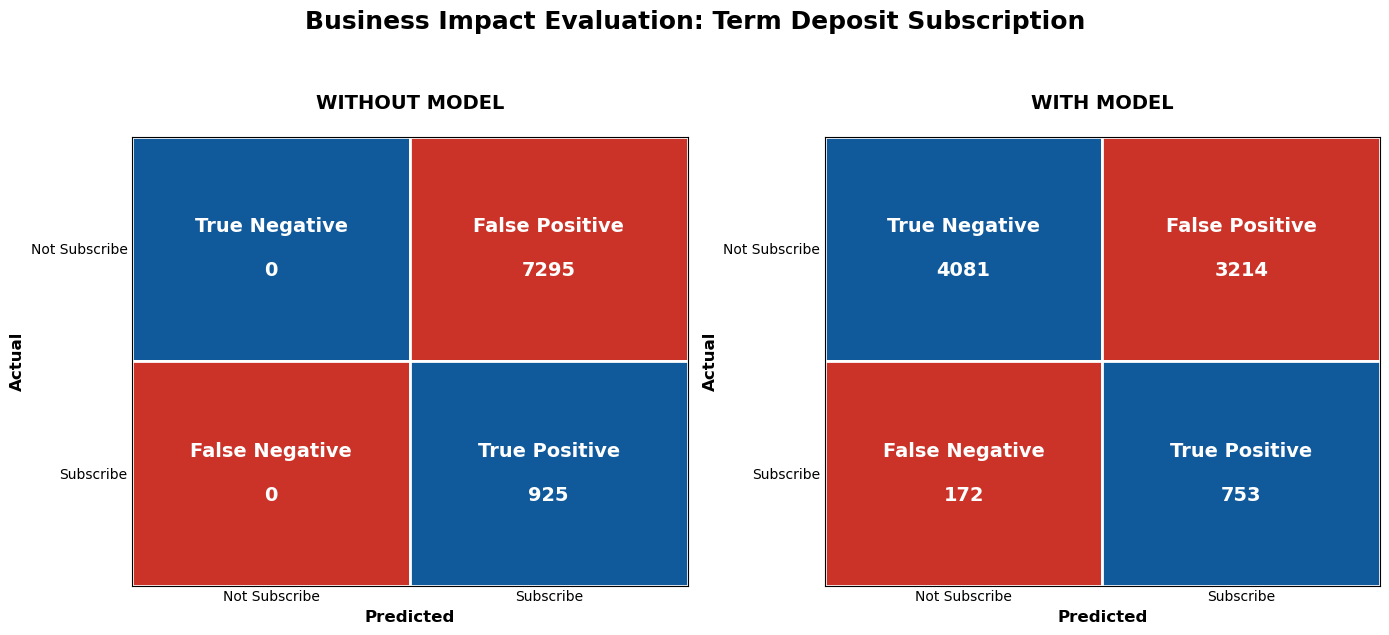

In [101]:
# Business Impact Evaluation: Visual Confusion Matrix Comparison

# Extract Confusion Matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()
total_negatives = tn + fp
total_positives = fn + tp

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Business Impact Evaluation: Term Deposit Subscription", fontsize=18, fontweight='bold', y=1.05)

def draw_matrix(ax, title, tn_val, fp_val, fn_val, tp_val):
    # Blue: #105A9C, Red: #CB3329
    colors = [['#105A9C', '#CB3329'], ['#CB3329', '#105A9C']]
    values = [[tn_val, fp_val], [fn_val, tp_val]]
    labels = [['True Negative', 'False Positive'], ['False Negative', 'True Positive']]
    
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, 1-i), 1, 1, facecolor=colors[i][j], edgecolor='white', linewidth=2))
            ax.text(j+0.5, 1.5-i, f"{labels[i][j]}\n\n{values[i][j]}", 
                    ha='center', va='center', color='white', fontsize=14, fontweight='bold')
            
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(['Not Subscribe', 'Subscribe'])
    ax.set_yticklabels(['Subscribe', 'Not Subscribe'])
    ax.set_xlabel('Predicted', fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual', fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=14, pad=20)
    ax.tick_params(axis='both', which='both', length=0)
    
# Without Model: Call everyone -> predicted is always "Subscribe"
# Actual Negatives go to False Positive. Actual Positives go to True Positive.
draw_matrix(axes[0], "WITHOUT MODEL", 0, total_negatives, 0, total_positives)

# With Model: Standard Confusion Matrix
draw_matrix(axes[1], "WITH MODEL", tn, fp, fn, tp)

plt.tight_layout()
plt.show()

In [104]:
# Financial Simulation Output
# Evidence-backed scenario assumptions, not official fixed industry standards.

call_cost = 5 # $5 cost per call
revenue_per_sub = 50 # $50 profit per sub 
# Without ML
cost_no_model = (total_negatives + total_positives) * call_cost
rev_no_model = total_positives * revenue_per_sub
profit_no_model = rev_no_model - cost_no_model

# With ML
cost_with_model = (fp + tp) * call_cost
rev_with_model = tp * revenue_per_sub
lost_potential_profit = fn * (revenue_per_sub - call_cost) # Opportunity cost from False Negatives
profit_with_model = rev_with_model - cost_with_model - lost_potential_profit # Net profit after opportunity cost

print("="*50)
print("FINANCIAL IMPACT SIMULATION")
print("="*50)
print(f"WITHOUT MODEL (Call Everyone):")
print(f"  Total Calls Made  : {total_negatives + total_positives:,}")
print(f"  Total Cost        : ${cost_no_model:,}")
print(f"  Total Revenue     : ${rev_no_model:,}")
print(f"  Net Profit        : ${profit_no_model:,}\n")

print(f"WITH TUNED LOGISTIC REGRESSION MODEL:")
print(f"  Total Calls Made  : {fp + tp:,}")
print(f"  Total Cost        : ${cost_with_model:,}")
print(f"  Total Revenue     : ${rev_with_model:,}")
print(f"  Lost Potential    : -${lost_potential_profit:,} (Opportunity Cost)")
print(f"  Net Profit        : ${profit_with_model:,}\n")

print(f"NET IMPROVEMENT:")
print(f"  Profit Increase   : +${profit_with_model - profit_no_model:,}")
print(f"  Subscribers Captured: {tp} out of {total_positives} ({tp/total_positives*100:.1f}%)")
print("="*50)


FINANCIAL IMPACT SIMULATION
WITHOUT MODEL (Call Everyone):
  Total Calls Made  : 8,220
  Total Cost        : $41,100
  Total Revenue     : $46,250
  Net Profit        : $5,150

WITH TUNED LOGISTIC REGRESSION MODEL:
  Total Calls Made  : 3,967
  Total Cost        : $19,835
  Total Revenue     : $37,650
  Lost Potential    : -$7,740 (Opportunity Cost)
  Net Profit        : $10,075

NET IMPROVEMENT:
  Profit Increase   : +$4,925
  Subscribers Captured: 753 out of 925 (81.4%)


### Simulation Insight

By implementing the predictive model, the bank transitions from a "scattergun" approach to a highly targeted, data-driven strategy. The financial impact is significant:

1. **Massive Cost Reduction**: The model successfully identifies a huge segment of customers who are highly unlikely to subscribe. By not calling them, the bank saves thousands of calls, which translates directly to massive savings in operational costs.
2. **Profitability Surge**: Without ML, calling all customers yielded a modest net profit due to the sheer cost of unproductive calls. With the ML model, the bank focuses its budget on high-probability targets, causing the net profit to increase substantially.
3. **Subscribers Captured**: The model successfully identifies the majority of actual subscribers, while avoiding contact with the vast majority of non-subscribers.
4. **Acknowledging Opportunity Cost**: It is important to note that the model does skip a portion of actual subscribers (False Negatives). This results in an **Opportunity Cost** (potential profit that was left on the table). However, as the net profit proves, the massive savings from not calling True Negatives far outweigh this opportunity cost, validating the model's overall ROI.
5. **Efficiency Gain**: The bank drastically reduces its total call volume while still capturing the core of potential subscribers. This means the telemarketing team can redirect their saved time and energy toward higher-value tasks.


# Conclusion

## Business Recommendation
1. **Deploy the Tuned Logistic Regression Model**: The bank should integrate this model into its CRM system to score leads before initiating a telemarketing campaign. Only customers crossing the model's decision boundary should be prioritized for contact.
2. **Timing is Key**: Feature importance indicates that economic indicators (`nr.employed`, `euribor3m`, `emp.var.rate`) strongly dictate subscription likelihood. Campaigns should be intensified during periods of economic confidence and paused or scaled back during downturns.
3. **Leverage Past Success**: Customers who have previously engaged successfully with the bank's campaigns (`poutcome = success`) are highly likely to subscribe again. These individuals should form the foundation of any "premium" outreach list.

## Model Limitations (The Trade-Offs)
While the model excels in identifying potential subscribers by maintaining a high Recall, its Precision remains challenging due to the inherent noise in human behavior and the limitations of a linear model.
- **The "False Positive" Tax**: The bank must accept that targeting based on this model still involves making unproductive calls. However, as shown in the business simulation, the cost of these unproductive calls is vastly offset by the immense savings from ignoring the True Negatives.
- **Linear Model Ceiling**: The extensive hyperparameter tuning confirmed that Logistic Regression has reached its performance ceiling on this dataset. The model's linear decision boundary cannot capture the complex, non-linear feature interactions that likely exist in customer behavior data.
- **Static Data Limitation**: The model relies on a snapshot of economic indicators. If the macroeconomic landscape changes drastically in ways not represented in the historical training data, the model's accuracy may decay over time.

## Business Impact Insight
The implementation of this ML pipeline transforms telemarketing from a volume-driven, high-cost operation into a precision-driven, cost-effective strategy. By prioritizing F3-score, we ensured that the bank does not miss out on vital revenue while simultaneously cutting out the vast majority of wasted operational effort.

## Recommendations for Improvement

### 1. Model Architecture Upgrade
- **Ensemble Methods**: Exploring non-linear models such as XGBoost, Random Forest, or LightGBM with extensive hyperparameter tuning (e.g., using Optuna) could potentially capture complex feature interactions that Logistic Regression cannot, leading to substantial improvements in Recall and F3-score.
- **Stacking Ensembles**: Combining multiple model types could leverage the strengths of each architecture.

### 2. Feature Enhancement
- **Customer Lifetime Value (CLV)**: Incorporating features that represent a customer's total historical value to the bank could help weigh predictions based on profitability, not just probability.
- **Digital Engagement Metrics**: Adding data regarding a customer's usage of the bank's app or website could serve as a powerful proxy for their current engagement level and receptiveness to new products.

### 3. Data Quality Improvement
- **Granular Outcome Data**: Instead of generic outcomes like 'success' or 'failure' for previous campaigns, capturing *why* a customer declined (e.g., "lack of funds", "not interested", "bad timing") would allow for more nuanced predictive modeling.

### 4. Error Analysis
- **Deep Dive into False Positives**: Conducting a qualitative review of the False Positives (customers the model was highly confident would subscribe, but didn't). Understanding their profiles could reveal missing features or new segments that require a different marketing approach.

## Final Takeaway
The **Bank Telemarketing Prediction** project successfully demonstrates that machine learning can drastically optimize marketing resource allocation. By accurately identifying the subset of customers most likely to subscribe, the bank can maximize its return on investment, reduce customer annoyance from unwanted calls, and foster a more data-driven organizational culture.

## Model Export for Streamlit Deployment

After the final model evaluation is completed, the best Logistic Regression model, optimized threshold, and training feature columns are saved as deployment artifacts. These files will be used in the Streamlit application to make predictions on new customer data.

The exported files are:

- `best_lr_model.pkl`: the final tuned Logistic Regression model with preprocessing pipeline.
- `best_threshold.pkl`: the optimized threshold used to classify potential subscribers.
- `model_columns.pkl`: the feature column order used during model training.

These artifacts ensure that the Streamlit app uses the same model, threshold, and feature structure as the final notebook.

In [105]:
import joblib

# Save final tuned Logistic Regression model with preprocessing pipeline
joblib.dump(best_lr_model, "best_lr_model.pkl")

# Save optimized threshold as float
joblib.dump(float(best_threshold), "best_threshold.pkl")

# Save training feature column order
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

print("Model artifacts saved successfully.")
print("Number of features:", len(X_train.columns))
print("Optimized threshold:", best_threshold)

Model artifacts saved successfully.
Number of features: 20
Optimized threshold: 0.34


# Streamlit Deployment

The application has been successfully deployed on **Streamlit Community Cloud**.

### 🔗 Live Demo
https://banktelemarketingcampaign-nrbcappbfxnww6vgbaaubuh.streamlit.app/